
## Exploratory data analysis


### Data understanding and assessment
Before any analysis, we need to understand what we have: data types, missing values, duplicates, and basic distributions.

In [386]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

In [387]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'canceled': '#E74C3C', 'not_canceled': '#2ECC71',
          'city': '#3498DB',     'resort': '#F39C12'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_csv('./data/hotel_bookings.csv')

In [ ]:
print('Dataset overview')
print(f'Rows : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Date range : Jul 2015 - Aug 2017') # from paper abstract
print(f'Hotels : {df["hotel"].unique()}')
print()
print(df.dtypes)

Dataset overview
Rows : 119,390
Columns : 32
Date range : Jul 2015 - Aug 2017
Hotels : <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str


- arrival_date_month is categorical, probably convert it to an int (map the month to a number), check the values if they're valid
-  children is a float, needs to be converted to int
- check all the categorical features and explore them for feature engineering

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': (missing / len(df) * 100).round(2),
    'dtype': df[missing.index].dtypes
}).sort_values('missing_pct', ascending=False)

print('Missing values')
print(missing)

Missing values
          missing_count  missing_pct    dtype
company          112593        94.31  float64
agent             16340        13.69  float64
country             488         0.41      str
children              4         0.00  float64


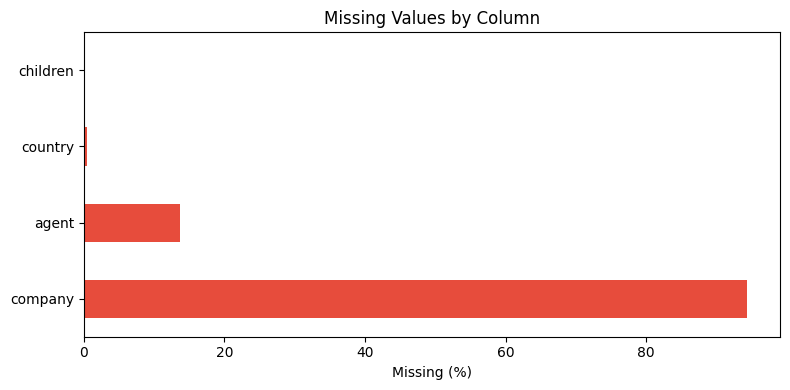

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
missing['missing_pct'].plot(kind='barh', ax=ax, color='#E74C3C')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.savefig('./eda_visuals/missing_values.png', bbox_inches='tight')
plt.show()

Accordign to the source of the dataset "company" is the company/entity that made the booking or responsible for paying the booking, and "agent" is the travel agency that made the booking. They both have "NULL" values; however, these do not represent a missing value but rather a "not applicable "value". So of a guest made a booking independently, then agent and company will both contain a "NULL" value. Dropping the column would not be the way to go for this.

In [8]:
# descriptive statistics
print('Descriptive statistics')
df.describe().T.round(2)

Descriptive statistics


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


- adr cannot be negative because its a spending rate, definitly has outliers because why is max 5.4k
- company and agent are IDs so they shouldnt be treated as numbers -> need to convert them to str
- seems to be outliers in days_in_waiting becauyse the 75% is 0 and max is 391, same thing for booking_changes
- adults max also seems to be an outlier because 55 is very high for one booking
- previous_bookings_not_canceled has the value 0 if the user didnt book before, so i think this needs to be checked out

what to check for outliers:
- lead_time, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, previous_cancellations (seems to be an important feature), previous_bookings_not_canceled, booking_changes

### Distribution visualization

In [31]:
outlier_features = [
    'adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list'
]

In [32]:
summary_rows = []
for col in outlier_features:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    outlier_mask = (s < low_fence) | (s > high_fence)

    summary_rows.append({
        'feature': col,
        'n': int(s.shape[0]),
        'zeros_%': round((s.eq(0).mean()) * 100, 2),
        'negatives_n': int((s < 0).sum()),
        'min': round(s.min(), 2),
        'p99': round(s.quantile(0.99), 2),
        'max': round(s.max(), 2),
        'iqr_low_fence': round(low_fence, 2),
        'iqr_high_fence': round(high_fence, 2),
        'iqr_outliers_n': int(outlier_mask.sum()),
        'iqr_outliers_%': round(outlier_mask.mean() * 100, 2),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('iqr_outliers_%', ascending=False)
display(summary_df)

,feature,n,zeros_%,negatives_n,min,p99,max,iqr_low_fence,iqr_high_fence,iqr_outliers_n,iqr_outliers_%
4,adults,119390,0.34,0,0.00,3.0,55.0,2.00,2.00,29710,24.88
9,booking_changes,119390,84.86,0,0.00,3.0,21.0,0.00,0.00,18076,15.14
5,children,119386,92.80,0,0.00,2.0,10.0,0.00,0.00,8590,7.20
7,previous_cancellations,119390,94.57,0,0.00,1.0,26.0,0.00,0.00,6484,5.43
0,adr,119390,1.64,1,-6.38,252.0,5400.0,-15.77,211.06,3793,3.18
10,days_in_waiting_list,119390,96.90,0,0.00,75.0,391.0,0.00,0.00,3698,3.10
8,previous_bookings_not_canceled,119390,96.97,0,0.00,3.0,72.0,0.00,0.00,3620,3.03
3,stays_in_week_nights,119390,6.40,0,0.00,10.0,50.0,-2.00,6.00,3354,2.81
1,lead_time,119390,5.31,0,0.00,444.0,737.0,-195.00,373.00,3005,2.52
6,babies,119390,99.23,0,0.00,0.0,10.0,0.00,0.00,917,0.77


In [309]:
def visualize_outliers(df, col, name):
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    axes[0].hist(s, bins=50, color='#5DADE2', alpha=0.85)
    axes[0].axvline(high_fence, color='#E74C3C', linestyle='--', linewidth=1.6, label=f'IQR high fence: {high_fence:.2f}')
    if low_fence > s.min():
        axes[0].axvline(low_fence, color='#E74C3C', linestyle='--', linewidth=1.2)
    axes[0].set_title(f'{col} - Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].legend(loc='upper right')

    axes[1].boxplot(s, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2E86C1'),
                    medianprops=dict(color='#C0392B', linewidth=2),
                    whiskerprops=dict(color='#2E86C1'),
                    capprops=dict(color='#2E86C1'),
                    flierprops=dict(marker='o', markersize=3, markerfacecolor='#E74C3C', markeredgecolor='#E74C3C', alpha=0.45))
    axes[1].set_title(f'{col} - Boxplot (Outlier View)')
    axes[1].set_xlabel(col)

    plt.suptitle(f'Outlier Diagnostics: {col}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./eda_visuals/{name}', bbox_inches='tight')
    plt.show()


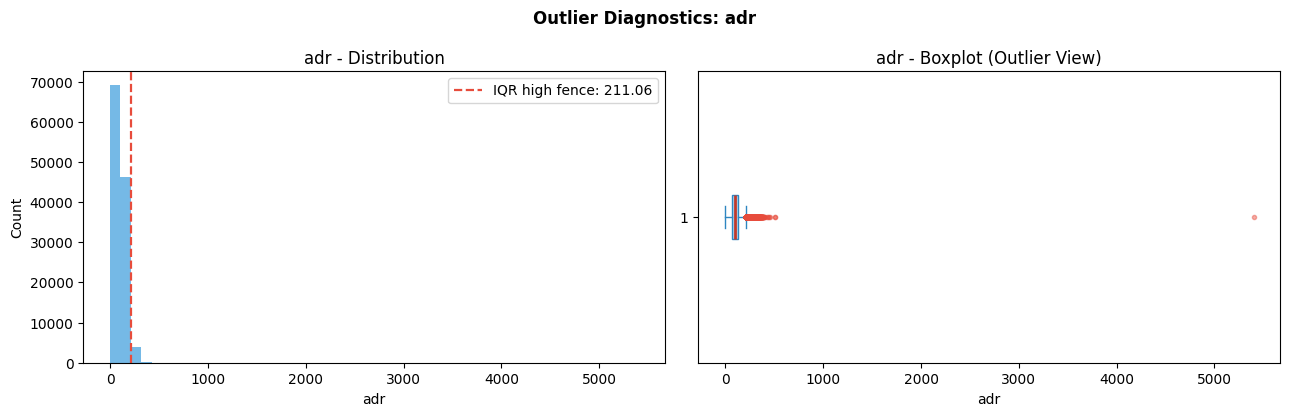

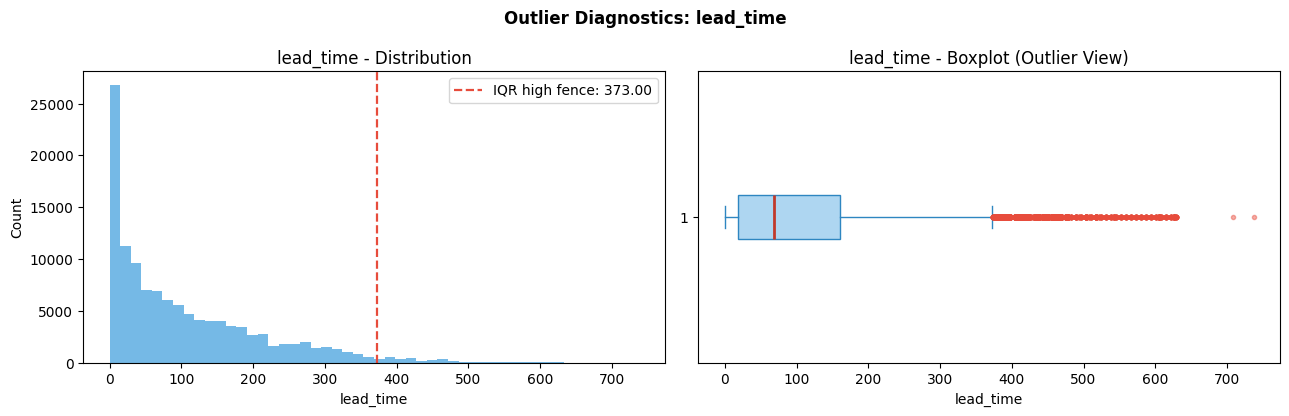

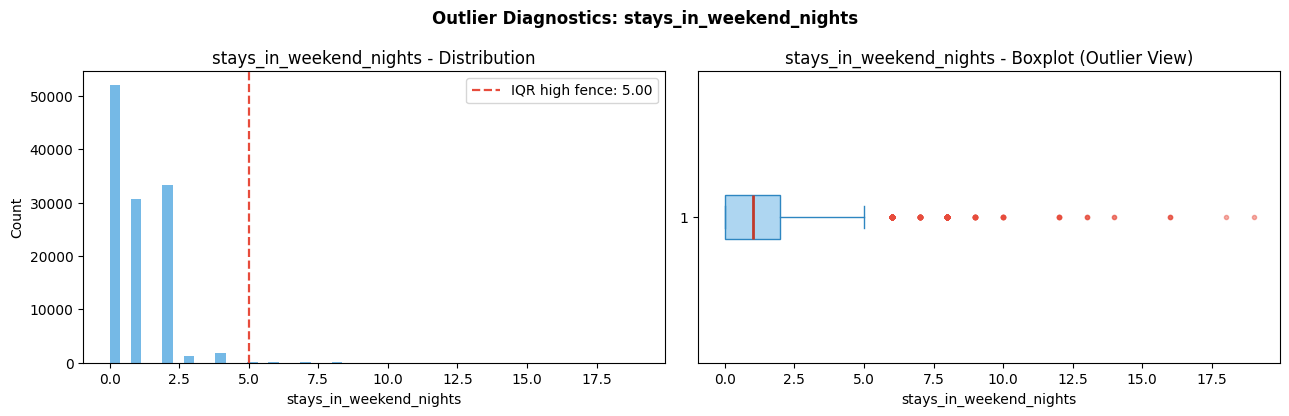

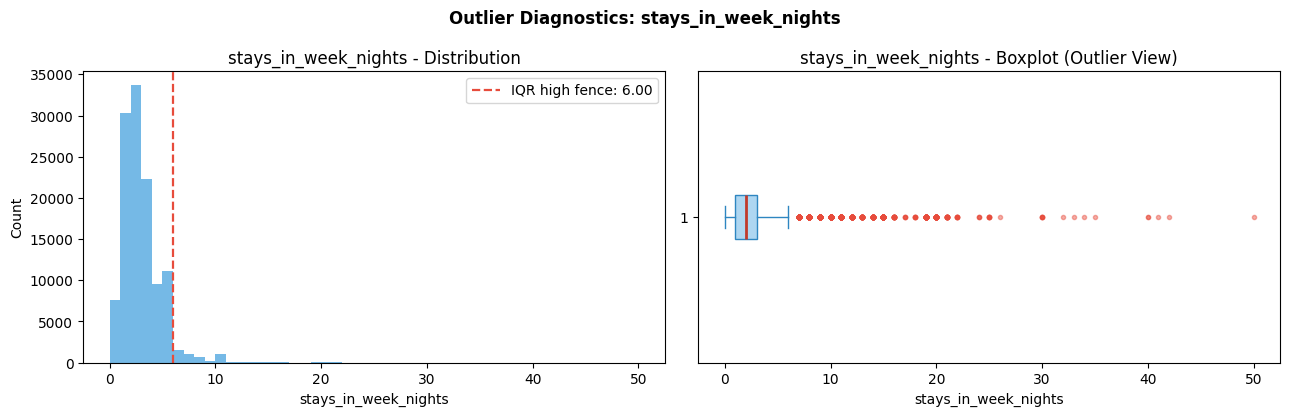

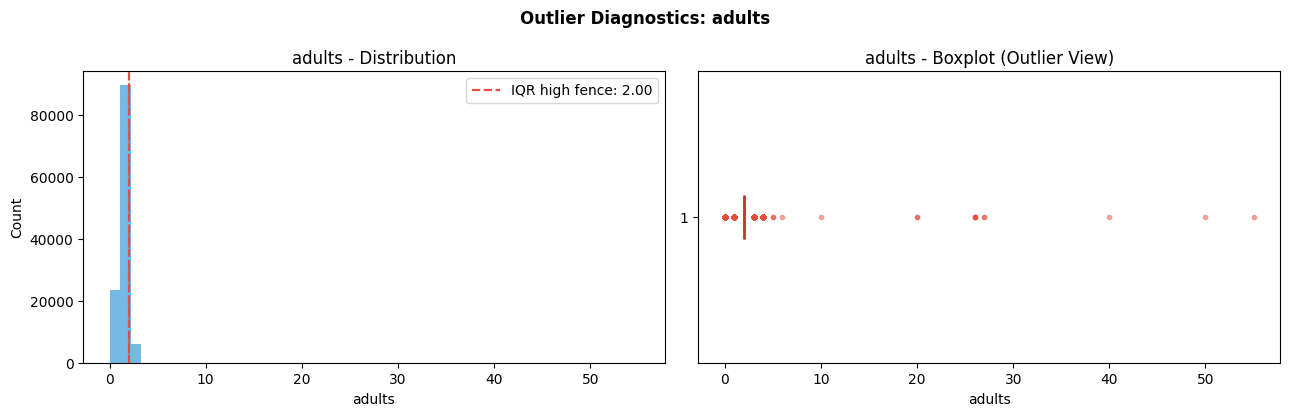

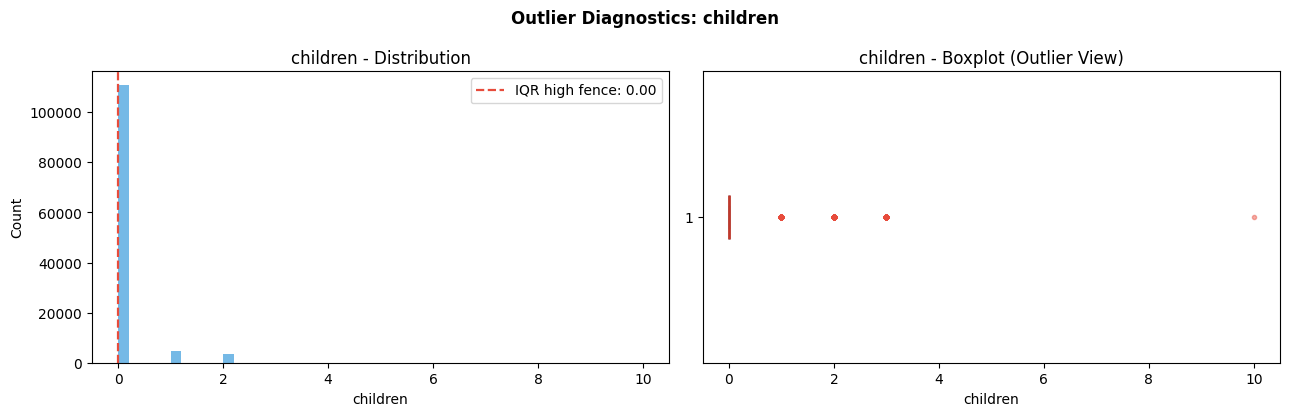

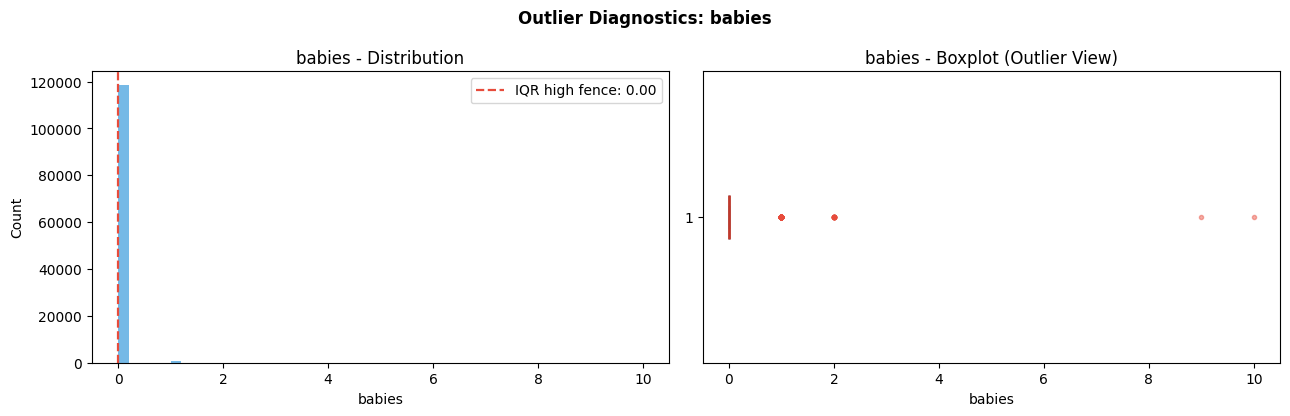

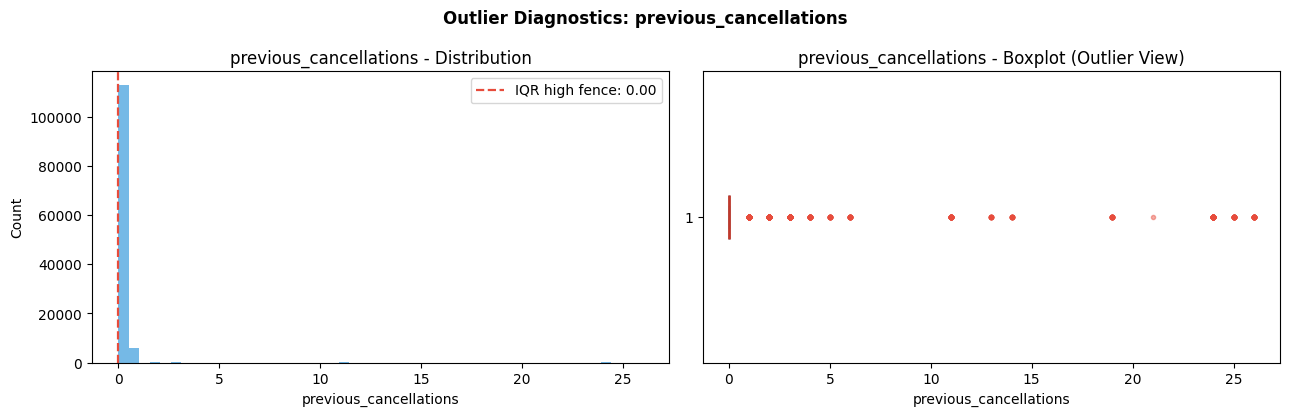

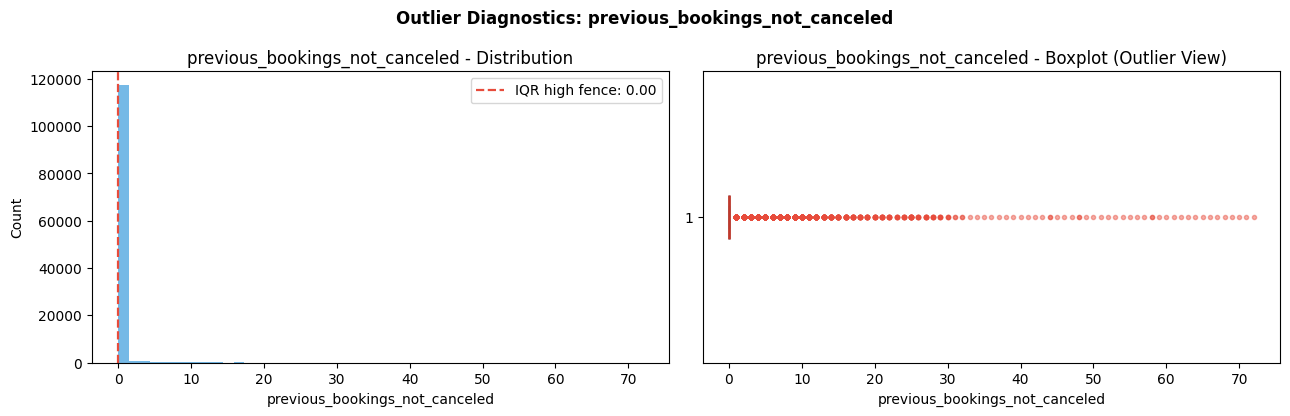

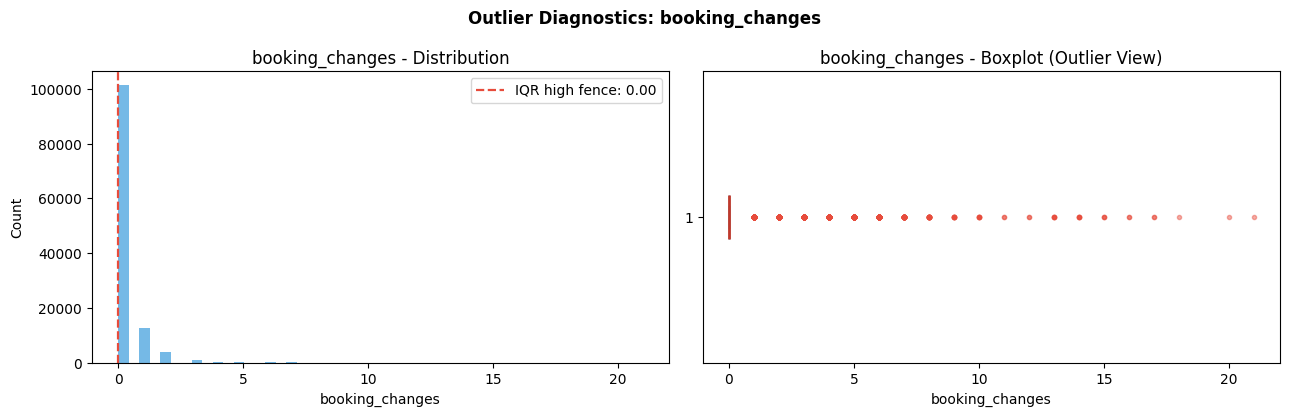

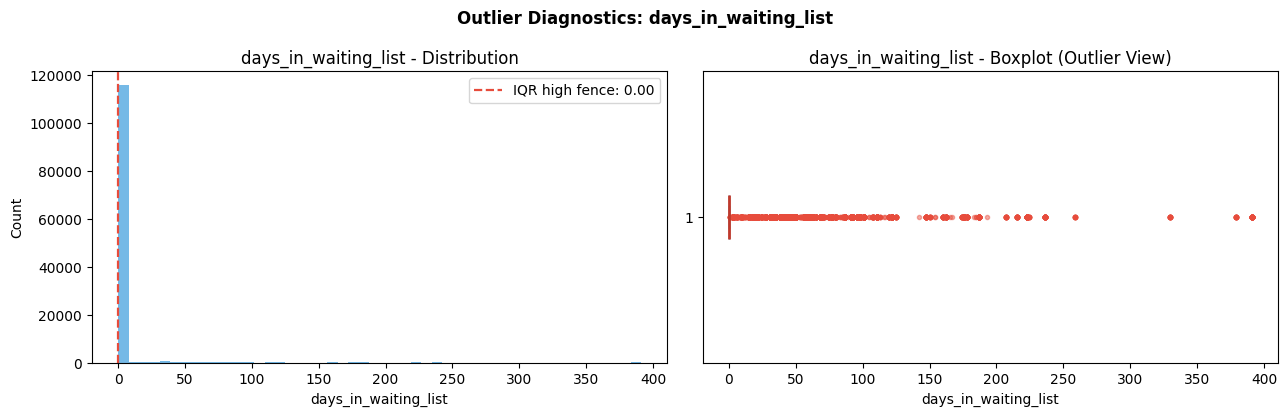

In [312]:
for col in outlier_features:
    name = f"original/{col}_outliers.png"
    visualize_outliers(df, col, name)

### Data cleaning
According to the source, the following needs to be accounted for:
- `children`, `country`, `agent`, `company` have real null values
- `NULL` strings in `agent` and `company` mean "not applicable" not missing
- Rows with 0 adults, 0 children, and 0 babies are phantom bookings
- `adr` has negative values which are data errors

In [313]:
# fix children and country null values --> null children = 0 and null country = 'Unknown'
df_clean = df.copy()
df_clean['children'] = df_clean['children'].fillna(0).astype(int)
df_clean['country'] = df_clean['country'].fillna('Unknown')

print(f'children nulls filled: {df["children"].isnull().sum()}') 
print(f'country nulls filled : {df["country"].isnull().sum()}')

# fix the agent and company values, if agent is null then its a direct booking from the customer so null gets replaced with direct
# if company is null then it means the booking was not made through a company so null gets replaced with none
# handling na
df_clean['agent']   = df_clean['agent'].fillna('Direct').astype(str)
df_clean['company'] = df_clean['company'].fillna('None').astype(str)
# handiling "null"
df_clean['agent'] = df_clean['agent'].replace(['NULL', 'null', 'Null'], np.nan).fillna('Direct').astype(str)
df_clean['company'] = df_clean['company'].replace(['NULL', 'null', 'Null'], np.nan).fillna('None').astype(str)

# make sure theyre all str
df_clean[['agent', 'company']] = df_clean[['agent', 'company']].astype(str)

# check how many phantom bookings there are and remove 
phantom_mask = (df_clean['adults'] == 0) & (df_clean['children'] == 0) & (df_clean['babies'] == 0)
print(f'Phantom bookings removed: {phantom_mask.sum()}')
df_clean = df_clean[~phantom_mask]

# adr is average daily rates, calculated as dividing the sum of all lodging transactions by the total number of staying nights
# this value cannot be negative so negative values are data errors that need to be removed
neg_adr = (df_clean['adr'] < 0).sum()
print(f'Negative ADR rows removed: {neg_adr}')
df_clean = df_clean[df_clean['adr'] >= 0]

children nulls filled: 4
country nulls filled : 488
Phantom bookings removed: 180
Negative ADR rows removed: 1


In [314]:
# dedup
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)

print(f"Removed duplicates: {before - after:,}")
print(f"Rows after dedup: {after:,}")


Removed duplicates: 31,980
Rows after dedup: 87,229


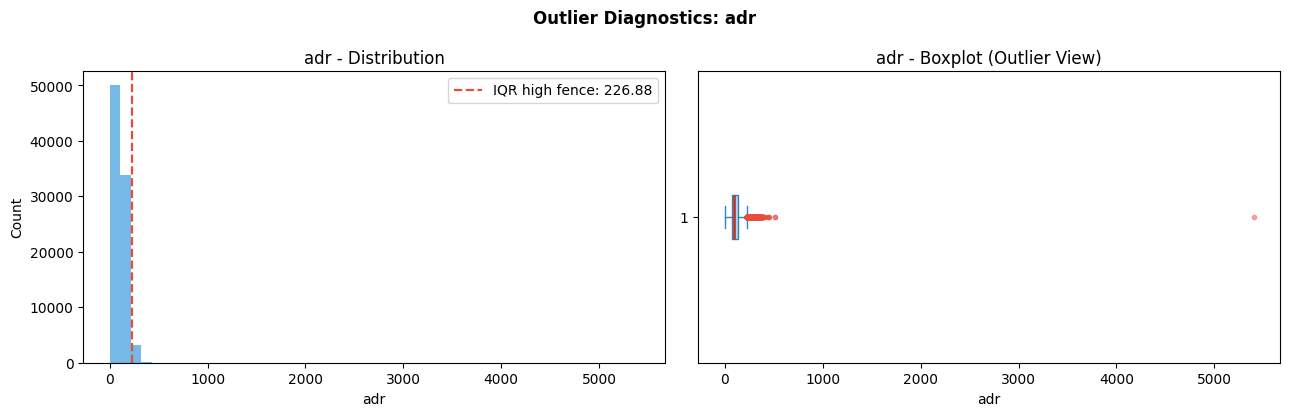

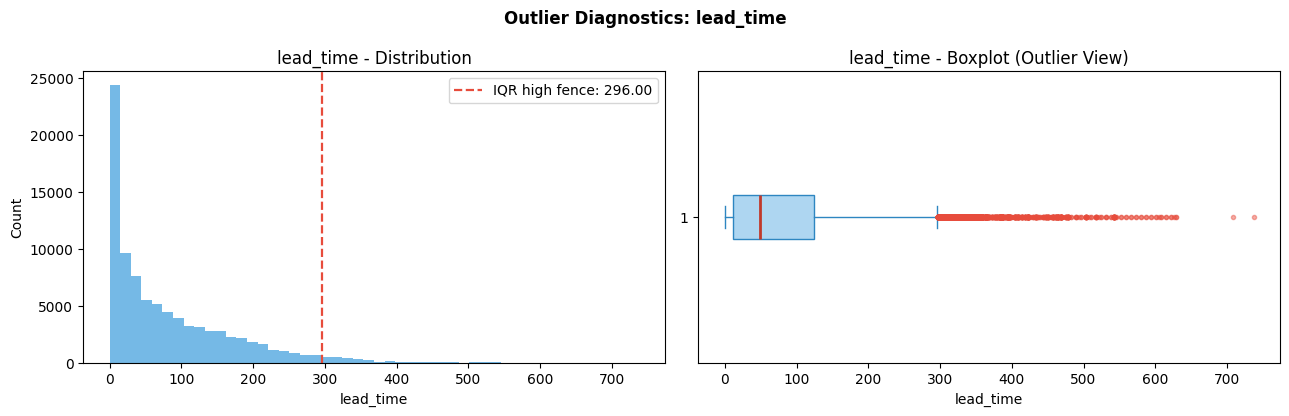

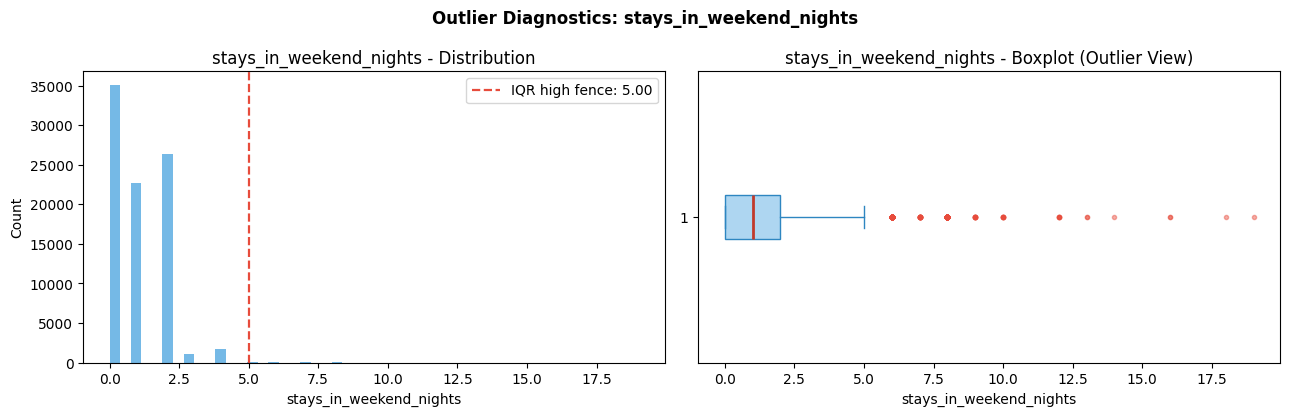

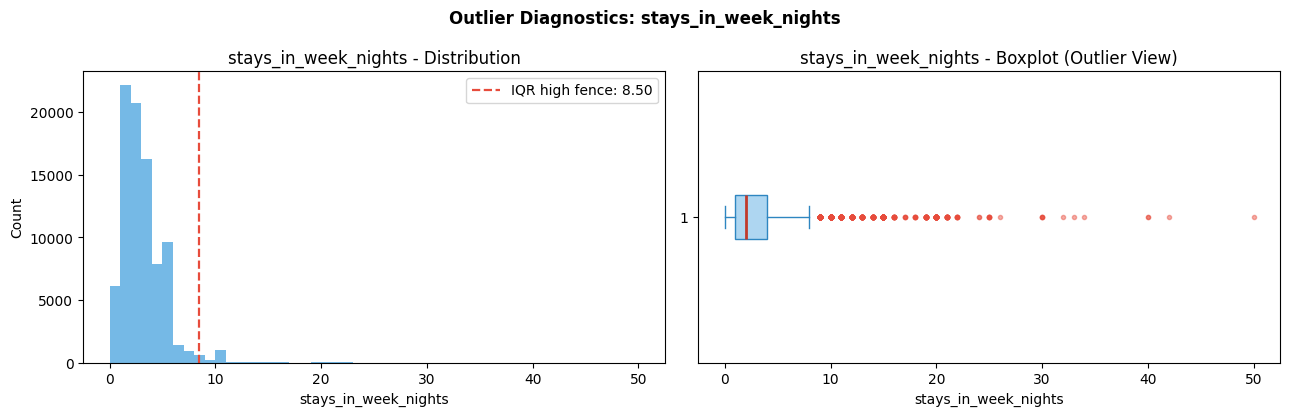

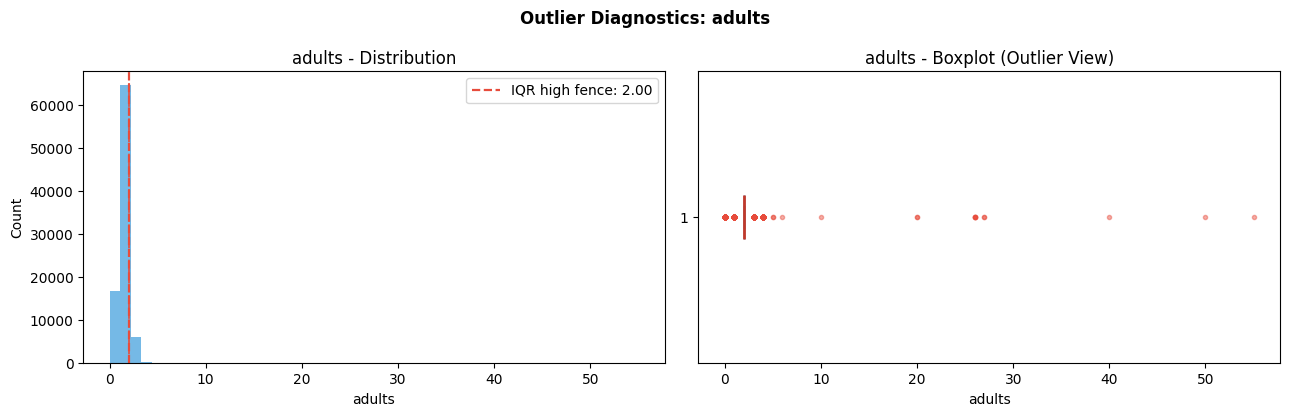

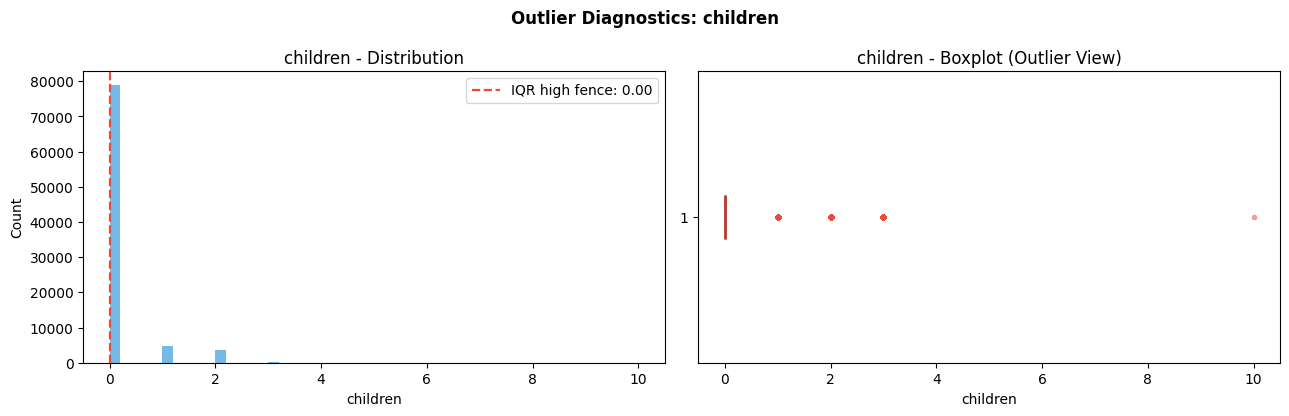

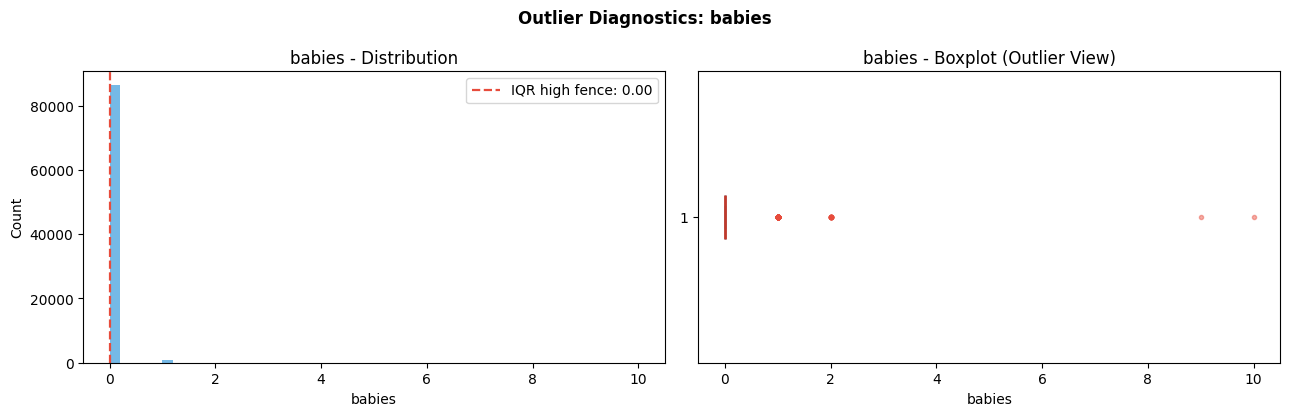

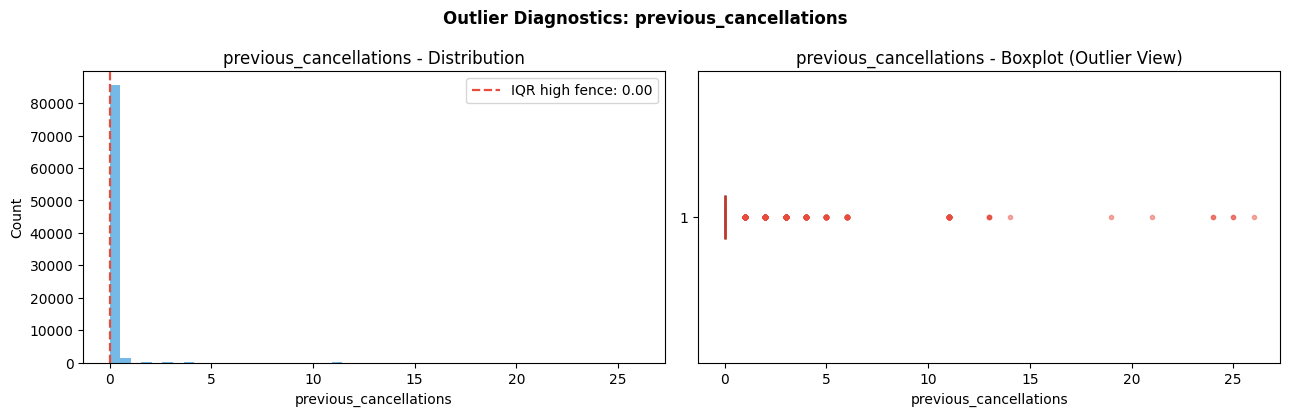

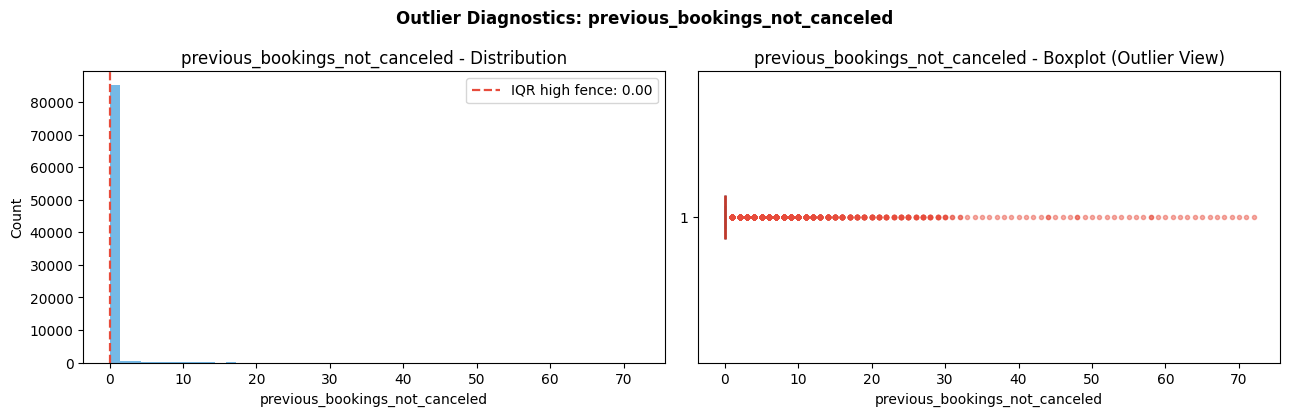

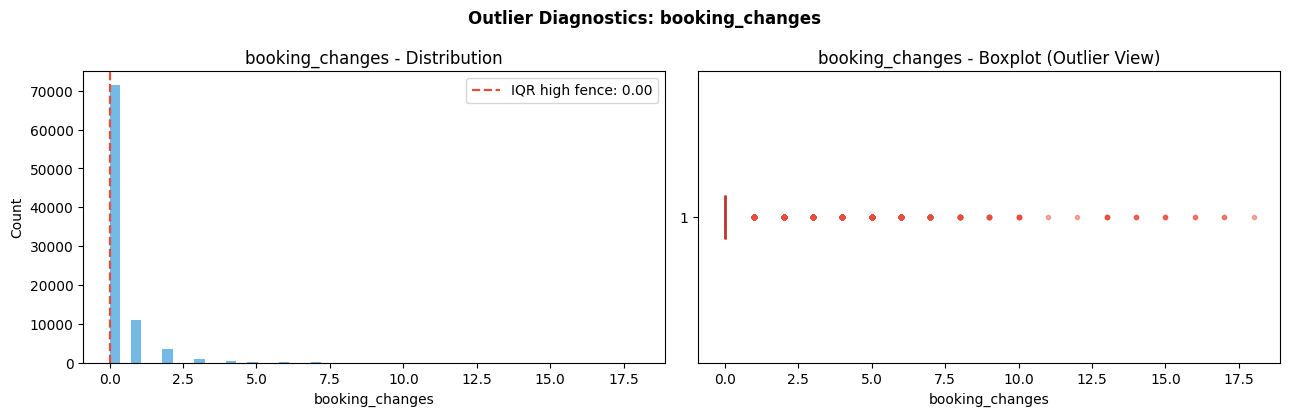

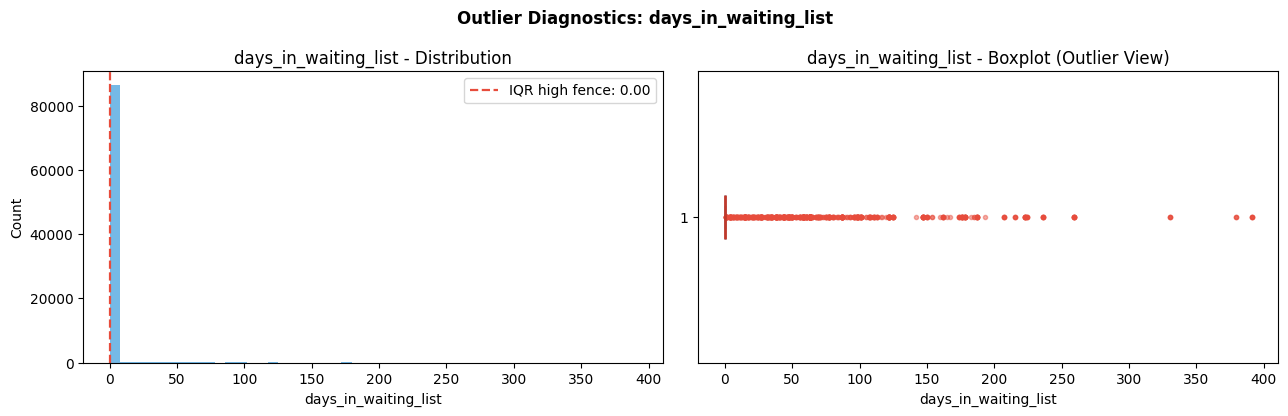

In [315]:
# visualize without duplicates

for col in outlier_features:
    name = f"deduplicated/{col}_deduplicated.png"
    visualize_outliers(df_clean, col, name)

In [316]:
# saving this for baseline testing 
df_clean.to_csv('./data/hotel_bookings_initial.csv', index=False)

#### Handling outliers

Winsorization

In [317]:
outliers_fixed = []

In [353]:
# -----------cap adr at 99.5 percentile
adr_cap = df_clean['adr'].quantile(0.995)
extreme_adr = (df_clean['adr'] > adr_cap).sum()
print(f'Extreme ADR rows to winsorize (>{adr_cap:.0f}): {extreme_adr}')
# flag for later analysis if needed
df_clean['adr_was_capped'] = (df_clean['adr'] > adr_cap).astype(int)
df_clean['adr'] = df_clean['adr'].clip(upper=adr_cap)
outliers_fixed.append('adr')

# ------------lead_time cap 99 percentile: 347 days before the booking
lead_cap = df_clean['lead_time'].quantile(0.99)
print(f'Extreme lead time rows to winsorize (>{lead_cap:.0f}): {(df_clean['lead_time'] > lead_cap).sum()}')
# flag
df_clean['lead_time_was_capped'] = (df_clean['lead_time'] > lead_cap).astype(int)
df_clean['lead_time'] = df_clean['lead_time'].clip(upper=lead_cap)
# log transform to reduce skew
df_clean['lead_time_log'] = np.log1p(df_clean['lead_time'])
outliers_fixed.append('lead_time')
outliers_fixed.append('lead_time_log')

# -----------weekend nights stays cap at 99.5 percentile
weekend_cap = df_clean['stays_in_weekend_nights'].quantile(0.995)
print(f'Extreme weekend stay rows to winsorize (>{weekend_cap:.0f}): {(df_clean['stays_in_weekend_nights'] > weekend_cap).sum()}')
# flag
df_clean['stays_weekend_was_capped'] = (df_clean['stays_in_weekend_nights'] > weekend_cap).astype(int)
df_clean['stays_in_weekend_nights'] = df_clean['stays_in_weekend_nights'].clip(upper=weekend_cap)
outliers_fixed.append('stays_in_weekend_nights')

# -----------week nights stays cap at 99.5 percentile
week_cap = df_clean['stays_in_week_nights'].quantile(0.995)
print(f'Extreme weekly stay rows to winsorize (>{week_cap:.0f}): {(df_clean['stays_in_week_nights'] > week_cap).sum()}')
# flag
df_clean['stays_week_was_capped'] = (df_clean['stays_in_week_nights'] > week_cap).astype(int)
df_clean['stays_in_week_nights'] = df_clean['stays_in_week_nights'].clip(upper=week_cap)
outliers_fixed.append('stays_in_week_nights')

# -----------adults cap at 6
ADULTS_MAX = 6
print(f'Extreme adult rows to winsorize (>{ADULTS_MAX}): {(df_clean['adults'] > ADULTS_MAX).sum()}')
# flag
df_clean['adults_was_capped'] = (df_clean['adults'] > ADULTS_MAX).astype(int)
df_clean['adults'] = df_clean['adults'].clip(upper=ADULTS_MAX)
outliers_fixed.append('adults')

# -----------children cap at 3
CHILDREN_MAX = 3
print(f'Extreme children rows to winsorize (>{CHILDREN_MAX}): {(df_clean['children'] > CHILDREN_MAX).sum()}')
# flag
df_clean['has_children'] = (df_clean['children'] > 0).astype(int)
df_clean['children_was_capped'] = (df_clean['children'] > CHILDREN_MAX).astype(int)
df_clean['children'] = df_clean['children'].clip(upper=CHILDREN_MAX)
outliers_fixed.append('children')

# -----------babies cap at 2
BABIES_MAX = 2
print(f'Extreme babies rows to winsorize (>{BABIES_MAX}): {(df_clean['babies'] > BABIES_MAX).sum()}')
# flag
df_clean['has_babies'] = (df_clean['babies'] > 0).astype(int)
df_clean['babies_was_capped'] = (df_clean['babies'] > BABIES_MAX).astype(int)
df_clean['babies'] = df_clean['babies'].clip(upper=BABIES_MAX)
outliers_fixed.append('babies')

# -----------booking changes cap at 99.5 percentile
book_change_cap = df_clean['booking_changes'].quantile(0.995)
print(f'Extreme booking changes rows to winsorize (>{book_change_cap}): {(df_clean["booking_changes"] > book_change_cap).sum()}')
# booking change flag
df_clean['has_booking_changes'] = (df_clean['booking_changes'] > 0).astype(int)
# flag
df_clean['booking_changes_was_capped'] = (df_clean['booking_changes'] > book_change_cap).astype(int)
df_clean['booking_changes'] = df_clean['booking_changes'].clip(upper=book_change_cap)
outliers_fixed.append('booking_changes')

# -----------days in waiting list cap at 99.5 percentile
wait_cap = df_clean['days_in_waiting_list'].quantile(0.995)
print(f'Extreme days in waiting list rows to winsorize (>{wait_cap}): {(df_clean["days_in_waiting_list"] > wait_cap).sum()}')
# flag
df_clean['has_waiting_list'] = (df_clean['days_in_waiting_list'] > 0).astype(int)
df_clean['days_waiting_was_capped'] = (df_clean['days_in_waiting_list'] > wait_cap).astype(int)

df_clean['days_in_waiting_list'] = df_clean['days_in_waiting_list'].clip(upper=wait_cap)
df_clean['days_in_waiting_list_log'] = np.log1p(df_clean['days_in_waiting_list'])
outliers_fixed.append('days_in_waiting_list')
outliers_fixed.append('days_in_waiting_list_log')

Extreme ADR rows to winsorize (>285): 435
Extreme lead time rows to winsorize (>347): 863
Extreme weekend stay rows to winsorize (>4): 281
Extreme weekly stay rows to winsorize (>10): 332
Extreme adult rows to winsorize (>6): 13
Extreme children rows to winsorize (>3): 1
Extreme babies rows to winsorize (>2): 2
Extreme booking changes rows to winsorize (>4.0): 245
Extreme days in waiting list rows to winsorize (>58.0): 435


For booking history, the problem is that the value 0 (for both cancellation and no cancellation history) can also mean that the person just doesn't have any previous bookings. This makes things ambiguous because if in previous_bookings_not_canceled there is a 0 we don't know if its because theres no history or becasuse the user has cancelled all their previous bookings (red flag they may be likely to cancel this one too).

In [372]:
df_clean['previous_bookings_not_canceled'].quantile(0.995)
(df_clean["previous_bookings_not_canceled"] > 9).sum()

np.int64(413)

In [373]:
# keep originals for traceability
df_clean['previous_cancellations_raw'] = df_clean['previous_cancellations']
df_clean['previous_bookings_not_canceled_raw'] = df_clean['previous_bookings_not_canceled']

#-----------previous cancellations cap at 99.8 percentile
prev_cancel_cap = df_clean['previous_cancellations'].quantile(0.998)
print(f'Extreme previous cancellations rows to winsorize (>{prev_cancel_cap}): {(df_clean["previous_cancellations_raw"] > prev_cancel_cap).sum()}')
# flag
df_clean['previous_cancellations_was_capped'] = (df_clean['previous_cancellations_raw'] > prev_cancel_cap).astype(int)
df_clean['previous_cancellations'] = df_clean['previous_cancellations_raw'].clip(upper=prev_cancel_cap)

# flag for cancelation
df_clean['has_prev_cancellations'] = (df_clean['previous_cancellations'] > 0).astype(int)
df_clean['previous_cancellations_log'] = np.log1p(df_clean['previous_cancellations'])
outliers_fixed.append('previous_cancellations')
outliers_fixed.append('previous_cancellations_log')

#-----------previous bookings not canceled cap at 99 percentile
prev_not_cancel_cap = df_clean['previous_bookings_not_canceled'].quantile(0.995)
print(f'Extreme previous bookings not canceled rows to winsorize (>{prev_not_cancel_cap}): {(df_clean["previous_bookings_not_canceled_raw"] > prev_not_cancel_cap).sum()}')
# flag
df_clean['previous_bookings_not_canceled_was_capped'] = (df_clean['previous_bookings_not_canceled_raw'] > prev_not_cancel_cap).astype(int)
df_clean['previous_bookings_not_canceled'] = df_clean['previous_bookings_not_canceled_raw'].clip(upper=prev_not_cancel_cap)

# flag for cancelation
df_clean['has_prev_not_canceled'] = (df_clean['previous_bookings_not_canceled'] > 0).astype(int)
df_clean['previous_bookings_not_canceled_log'] = np.log1p(df_clean['previous_bookings_not_canceled'])
outliers_fixed.append('previous_bookings_not_canceled')
outliers_fixed.append('previous_bookings_not_canceled_log')

# check if theres any history, basically to help with the ambiguous 0 flag
df_clean['has_any_history'] = ((df_clean['previous_cancellations'] + df_clean['previous_bookings_not_canceled']) > 0).astype(int)

# cancellation propensity among known previous bookings
prev_total = df_clean['previous_cancellations'] + df_clean['previous_bookings_not_canceled']
df_clean['prev_cancel_ratio'] = np.where(prev_total > 0, df_clean['previous_cancellations'] / prev_total, 0.0)

Extreme previous cancellations rows to winsorize (>2.0): 166
Extreme previous bookings not canceled rows to winsorize (>9.0): 413


In [374]:
# summary
flag_cols = [c for c in df_clean.columns if c.endswith('_was_capped')]
print(df_clean[flag_cols].sum().sort_values(ascending=False))


lead_time_was_capped                         863
adr_was_capped                               435
days_waiting_was_capped                      435
previous_bookings_not_canceled_was_capped    413
stays_week_was_capped                        332
stays_weekend_was_capped                     281
booking_changes_was_capped                   245
previous_cancellations_was_capped            166
adults_was_capped                             13
babies_was_capped                              2
children_was_capped                            1
dtype: int64


In [376]:
df_clean.shape

(87229, 57)

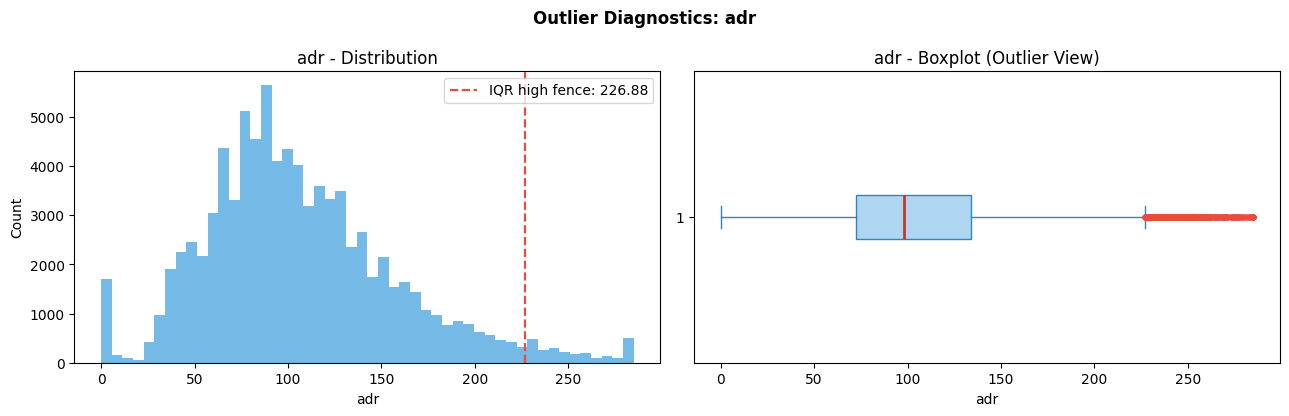

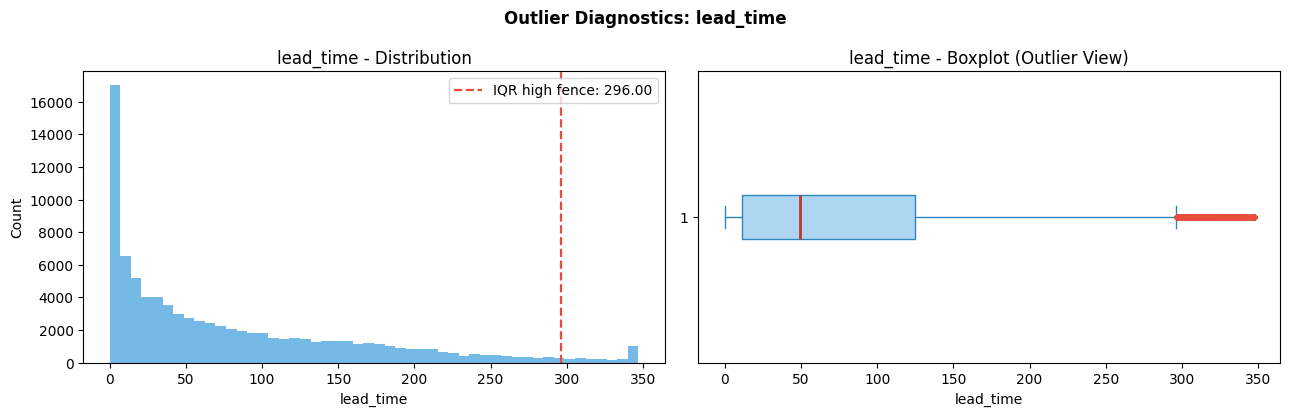

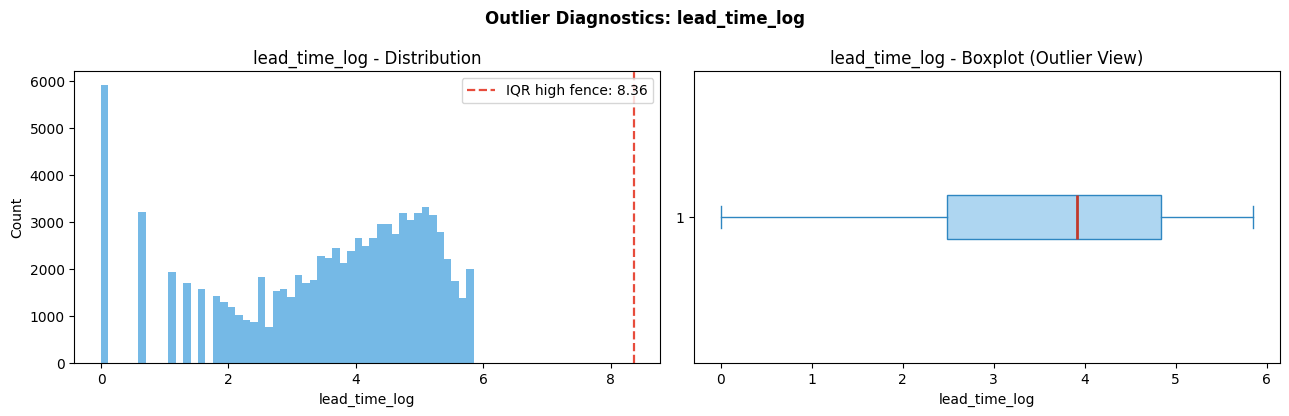

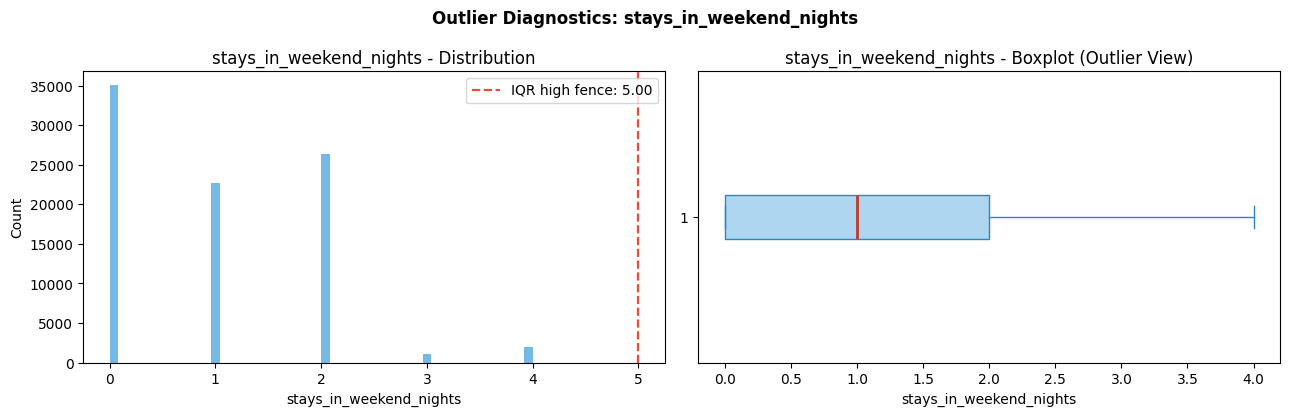

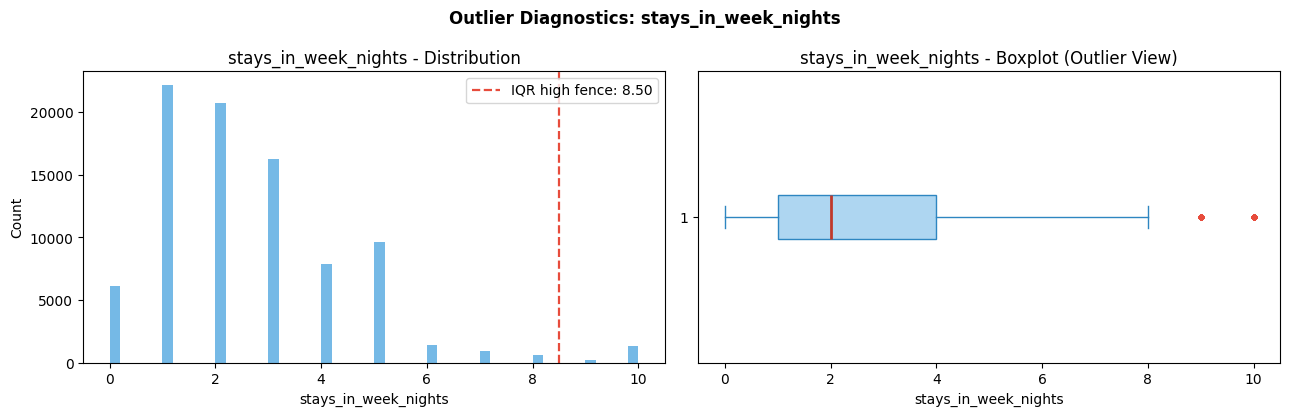

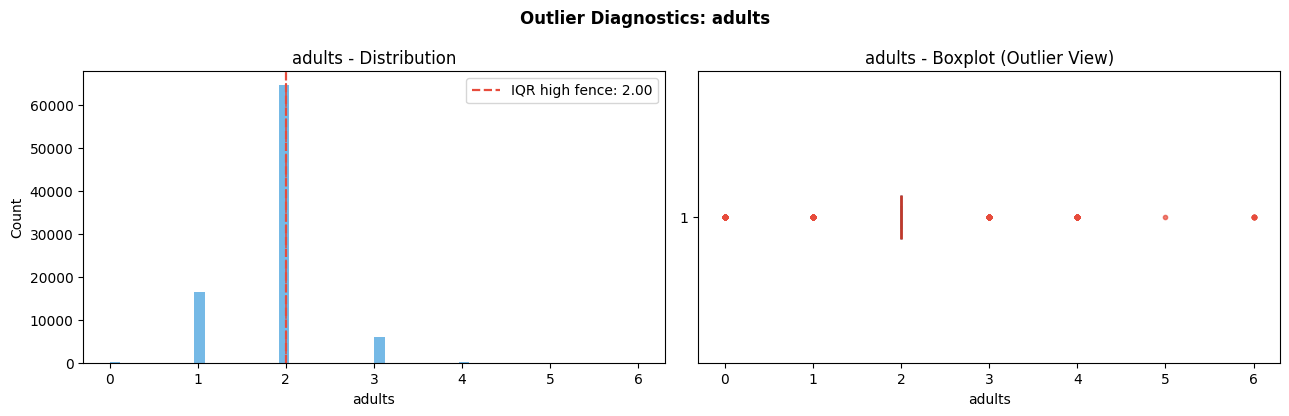

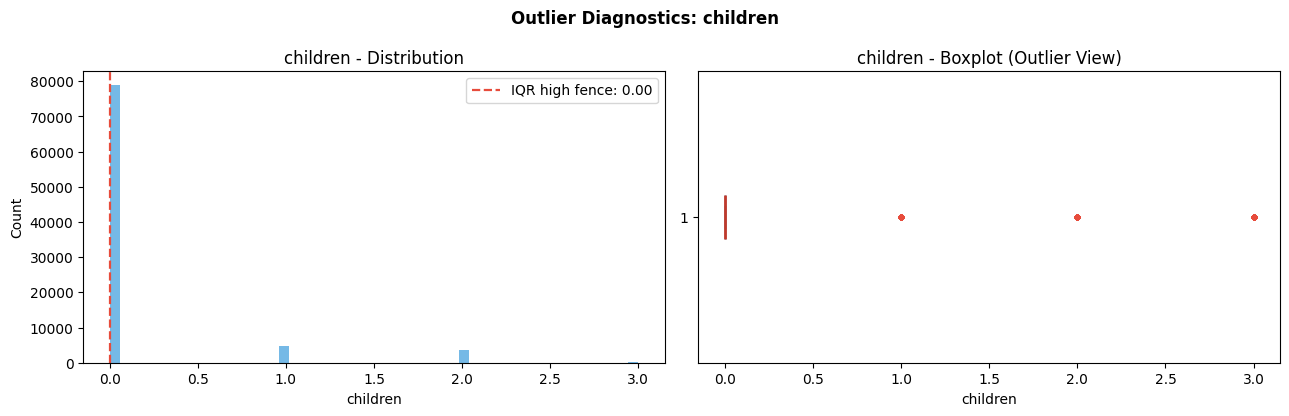

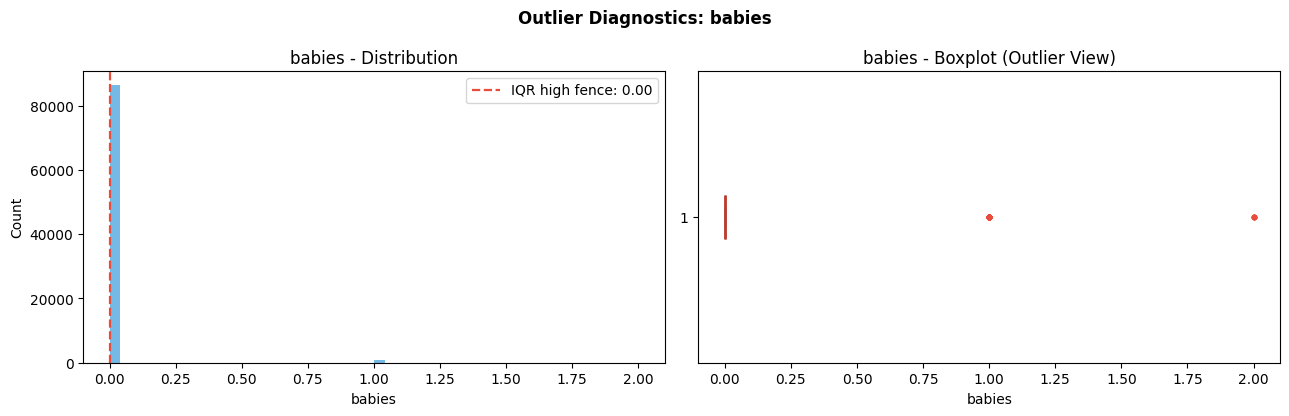

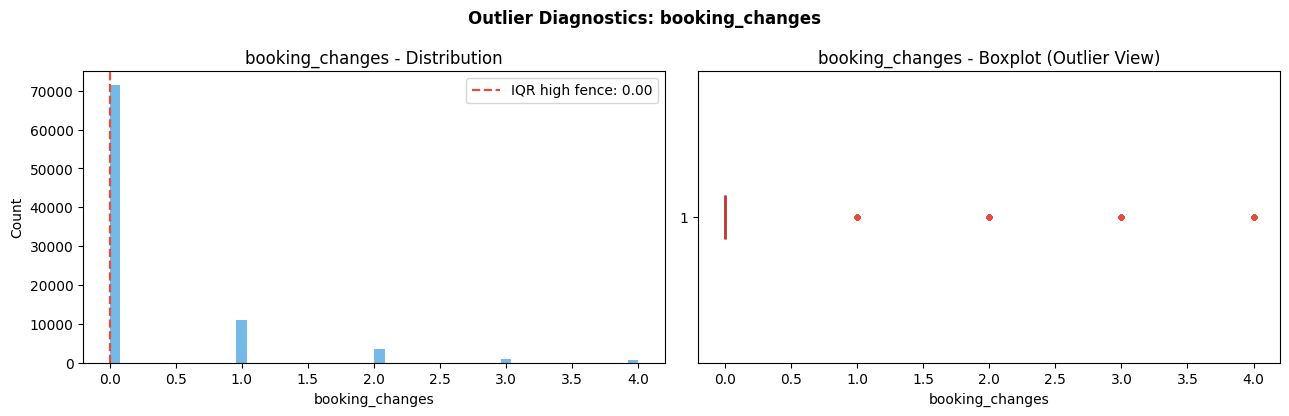

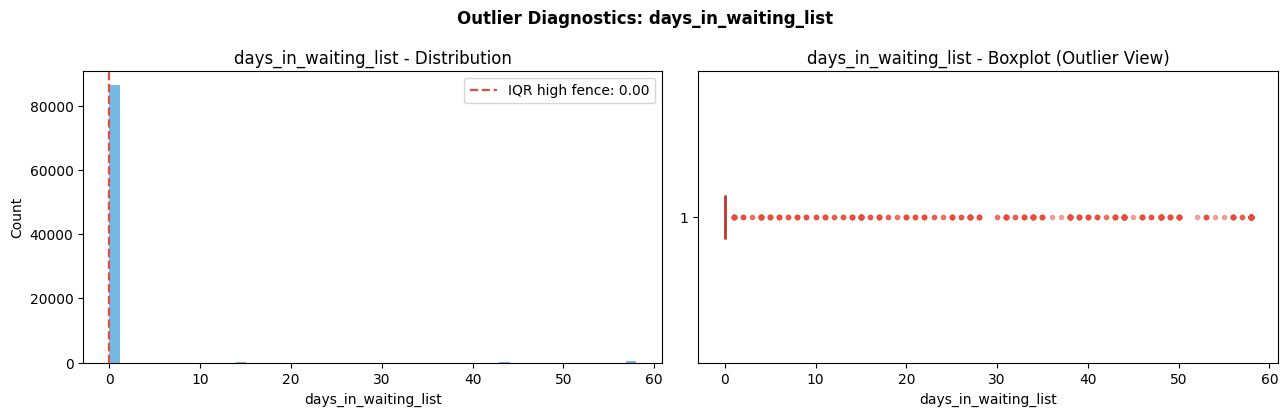

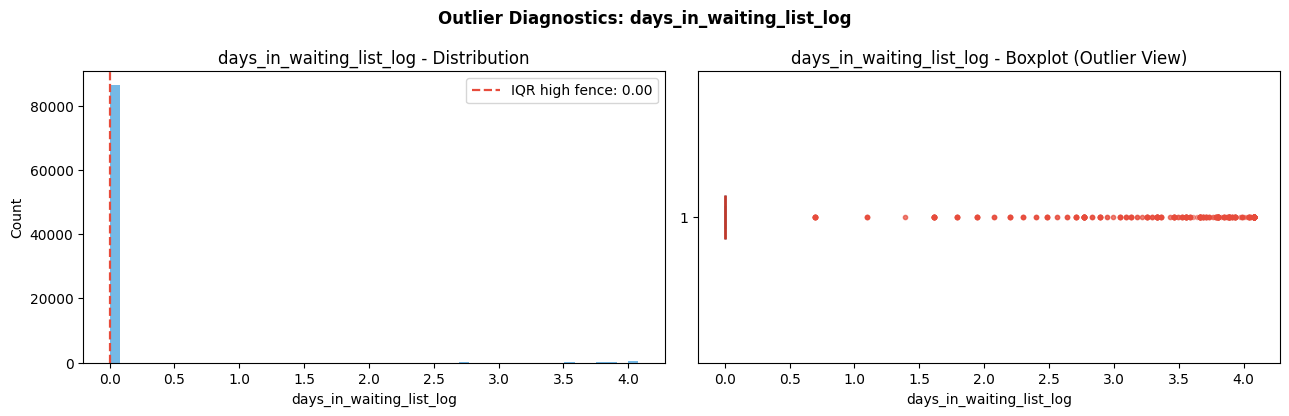

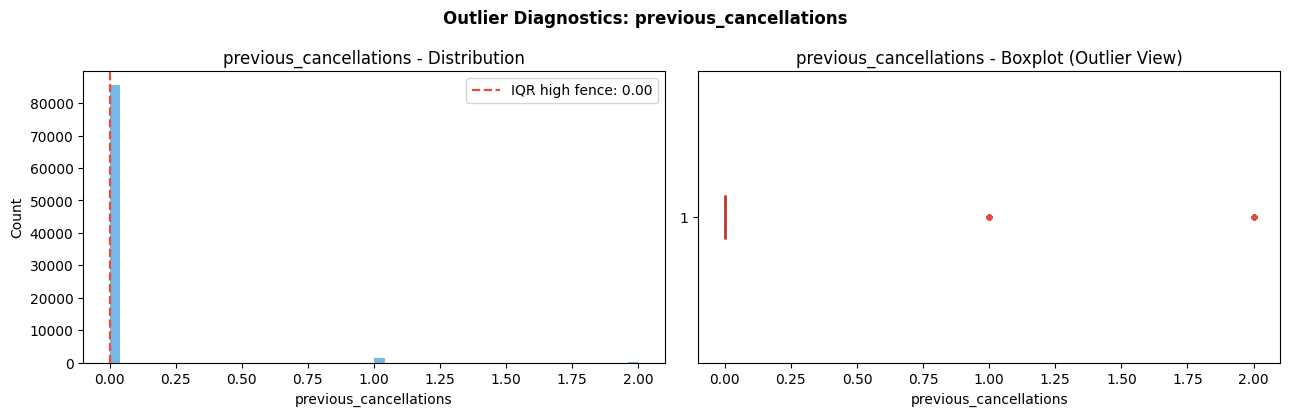

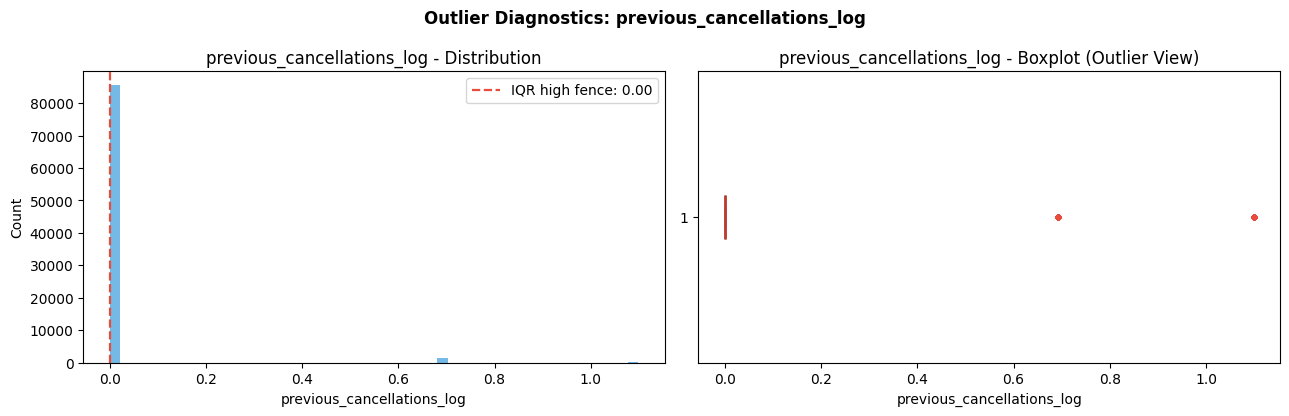

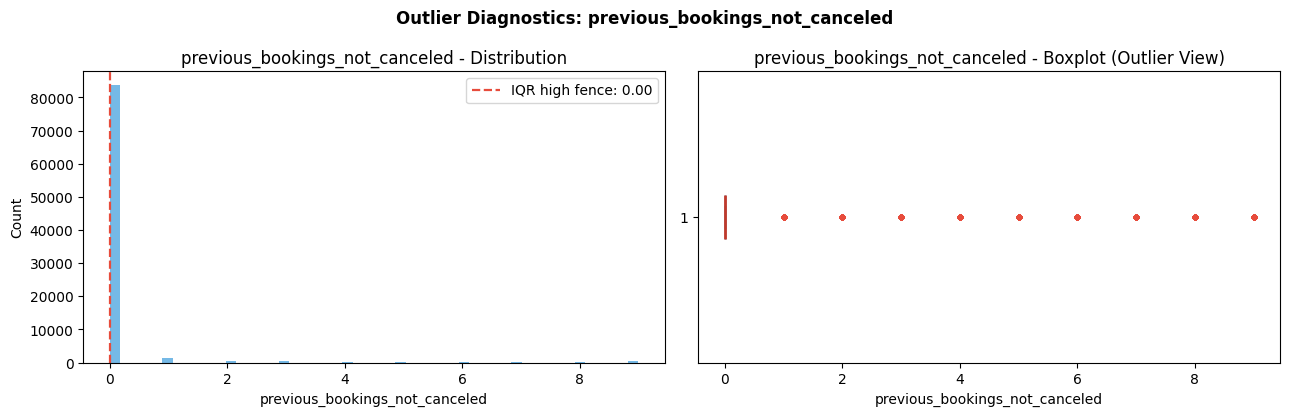

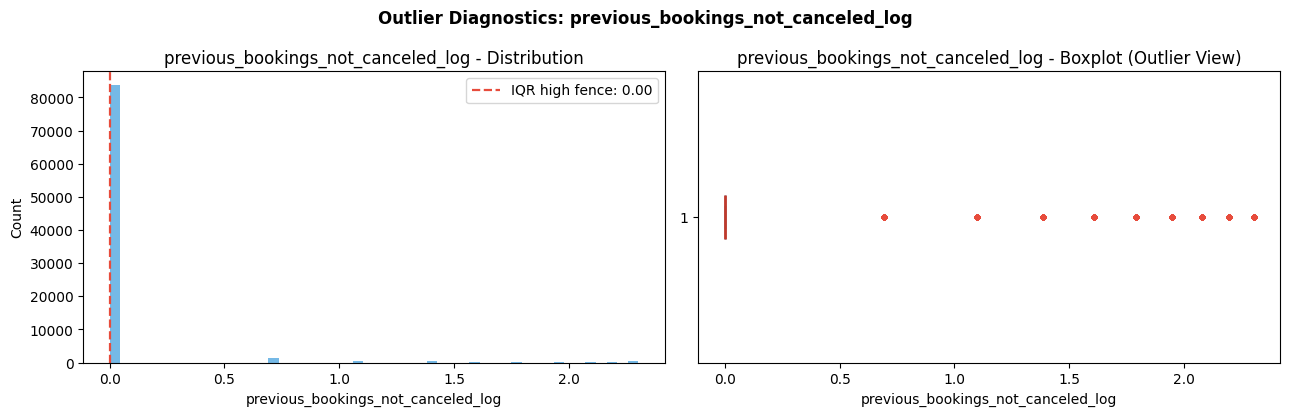

In [377]:
for col in outliers_fixed:
    if "log" not in col:  # non-log features
        visualize_outliers(df_clean, col, f"winsorized/{col}_winsorized.png")
    else:
        visualize_outliers(df_clean, col, f"winsorized/{col}_log.png")

In [381]:
# dedup
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

In [382]:
print(f'Final cleaned dataset: {df_clean.shape}')

Final cleaned dataset: (87224, 57)


In [383]:
print("Validation summary:")
print(f"Rows: {len(df_clean):,} | Cols: {df_clean.shape[1]}")

# missing values
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n[1] Missing values")
if missing.empty:
    print("No missing values found.")
else:
    display(missing.to_frame("missing_count"))
    display((missing / len(df_clean) * 100).round(3).to_frame("missing_pct"))

# duplicates
dups = df_clean.duplicated().sum()
print("\n[2] Duplicates")
print(f"Duplicate rows: {dups:,} ({dups/len(df_clean)*100:.2f}%)")

# business-rule checks
print("\n[3] Business-rule checks")
print(f"Negative ADR rows: {(df_clean['adr'] < 0).sum():,}")

phantom = ((df_clean['adults'] == 0) & (df_clean['children'] == 0) & (df_clean['babies'] == 0)).sum()
print(f"Phantom bookings (all guests 0): {phantom:,}")

# If you used these caps, validate them:
if 'adults' in df_clean.columns:
    print(f"Adults max: {df_clean['adults'].max()}")
if 'children' in df_clean.columns:
    print(f"Children max: {df_clean['children'].max()}")
if 'babies' in df_clean.columns:
    print(f"Babies max: {df_clean['babies'].max()}")

# target balance
print("\n[4] Target distribution (is_canceled)")
target_dist = df_clean['is_canceled'].value_counts(dropna=False)
target_pct = (target_dist / len(df_clean) * 100).round(2)
display(pd.DataFrame({"count": target_dist, "pct": target_pct}))

# capping flags summary 
print("\n[5] Capping flags summary")
flag_cols = [c for c in df_clean.columns if c.endswith('_was_capped')]
if flag_cols:
    flag_summary = pd.DataFrame({
        "capped_n": df_clean[flag_cols].sum().astype(int),
        "capped_pct": (df_clean[flag_cols].mean() * 100).round(3)
    }).sort_values("capped_pct", ascending=False)
    display(flag_summary)
else:
    print("No *_was_capped columns found.")

# numeric sanity snapshot
print("\n[6] Numeric sanity snapshot")
num_cols = ['adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'babies', 'previous_cancellations',
            'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list']
num_cols = [c for c in num_cols if c in df_clean.columns]

sanity = df_clean[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T[
    ['min', '50%', '90%', '95%', '99%', 'max']
]
display(sanity)

print("\nValidation completed.")


Validation summary:
Rows: 87,224 | Cols: 57

[1] Missing values
No missing values found.

[2] Duplicates
Duplicate rows: 0 (0.00%)

[3] Business-rule checks
Negative ADR rows: 0
Phantom bookings (all guests 0): 0
Adults max: 6
Children max: 3
Babies max: 2

[4] Target distribution (is_canceled)


,count,pct
is_canceled,,
0,63218,72.48
1,24006,27.52



[5] Capping flags summary


,capped_n,capped_pct
lead_time_was_capped,863,0.989
adr_was_capped,435,0.499
days_waiting_was_capped,435,0.499
previous_bookings_not_canceled_was_capped,413,0.473
stays_week_was_capped,332,0.381
stays_weekend_was_capped,281,0.322
booking_changes_was_capped,240,0.275
previous_cancellations_was_capped,166,0.190
adults_was_capped,13,0.015
babies_was_capped,2,0.002



[6] Numeric sanity snapshot


,min,50%,90%,95%,99%,max
adr,0.0,98.2,174.0,204.151,261.6309,285.0
lead_time,0.0,49.0,204.0,256.000,347.0000,347.0
stays_in_weekend_nights,0.0,1.0,2.0,2.000,4.0000,4.0
stays_in_week_nights,0.0,2.0,5.0,6.000,10.0000,10.0
adults,0.0,2.0,2.0,3.000,3.0000,6.0
children,0.0,0.0,0.0,1.000,2.0000,3.0
babies,0.0,0.0,0.0,0.000,1.0000,2.0
previous_cancellations,0.0,0.0,0.0,0.000,1.0000,2.0
previous_bookings_not_canceled,0.0,0.0,0.0,0.000,5.0000,9.0
booking_changes,0.0,0.0,1.0,2.000,3.0000,4.0



Validation completed.


### Export final cleaned dataset

In [384]:
# saving this for baseline testing 
df_clean.to_csv('./data/hotel_bookings_cleaned.csv', index=False)

### Univariate analysis

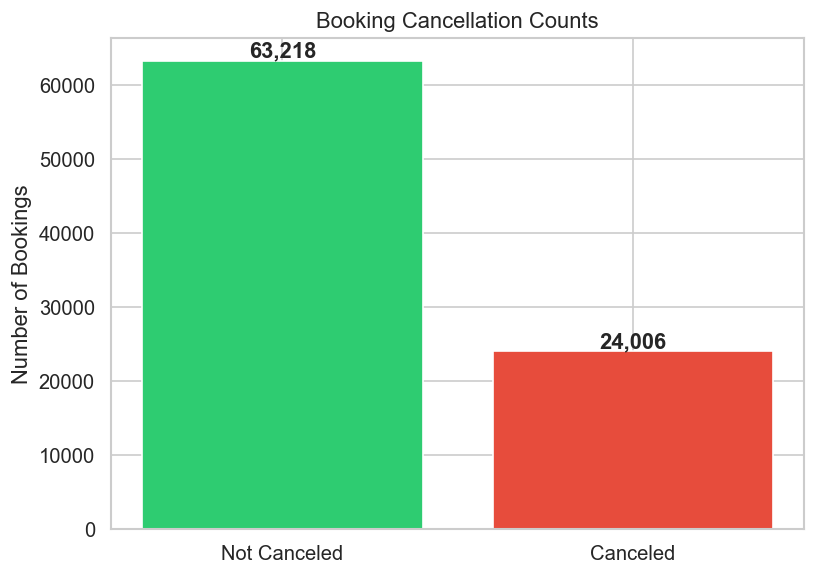

Total bookings: 87,224
Not Canceled: 63,218 (72.5%)
Canceled: 24,006 (27.5%)


In [ ]:
# target variable distribution
cancel_counts = df_clean['is_canceled'].value_counts()
cancel_rate   = df_clean['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))

# bar chart
ax.bar(['Not Canceled', 'Canceled'], cancel_counts.values,
       color=['#2ECC71', '#E74C3C'])
ax.set_title('Booking Cancellation Counts')
ax.set_ylabel('Number of Bookings')

for i, v in enumerate(cancel_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./eda_visuals/univariate/1_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'Total bookings: {len(df_clean):,}')
print(f'Not Canceled: {cancel_counts[0]:,} ({100 - cancel_rate:.1f}%)')
print(f'Canceled: {cancel_counts[1]:,} ({cancel_rate:.1f}%)')

There's inbalance in the target variable so a few things need to be done:
- stratified splits
- class weighing 
- oversampling 

In [415]:
# helper functions 
def plot_count_pct(series, title, xlabel, save_name, top_n=None, rotate=0, color='#3498DB'):
    s = series.copy()
    if top_n is not None:
        vc = s.value_counts(dropna=False)
        top_vals = vc.head(top_n).index
        s = s.where(s.isin(top_vals), other='Other')

    counts = s.value_counts(dropna=False)
    pct = (counts / counts.sum() * 100).round(1)

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of Bookings')
    ax.tick_params(axis='x', rotation=rotate)

    y_offset = max(counts.values) * 0.01
    for bar, c, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
                f'{c:,}\n({p}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    # plt.savefig(f'./eda_visuals/univariate/{save_name}', bbox_inches='tight')
    plt.show()

def plot_zero_nonzero(df, col, save_name):
    zero_n = (df[col] == 0).sum()
    non_zero_n = (df[col] != 0).sum()
    total = len(df)

    vals = [zero_n, non_zero_n]
    pct = [zero_n / total * 100, non_zero_n / total * 100]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Zero', 'Non-zero'], vals, color=['#5DADE2', '#E74C3C'])
    ax.set_title(f'{col}: Zero vs Non-zero', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Bookings')

    for bar, c, p in zip(bars, vals, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{c:,} ({p:.1f}%)', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'./eda_visuals/univariate/{save_name}', bbox_inches='tight')
    plt.show()

In [411]:
# encode month
month_to_num = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df_clean['arrival_month_num'] = df_clean['arrival_date_month'].map(month_to_num)

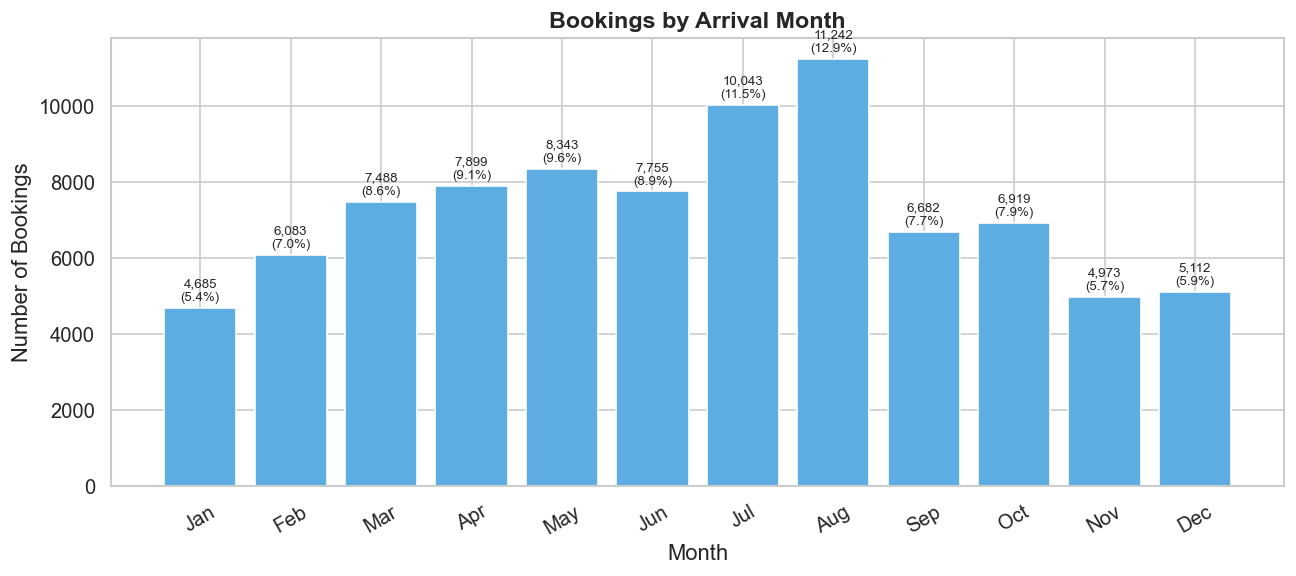

In [ ]:
# plot month distribution
month_counts = df_clean['arrival_month_num'].value_counts().sort_index()
month_pct = (month_counts / len(df_clean) * 100).round(1)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(month_counts.index, month_counts.values, color='#5DADE2')
ax.set_title('Bookings by Arrival Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)

y_offset = month_counts.max() * 0.01
for bar, c, p in zip(bars, month_counts.values, month_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
            f'{c:,}\n({p}%)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./eda_visuals/univariate/14_month_frequency_encoded.png', bbox_inches='tight')
plt.show()


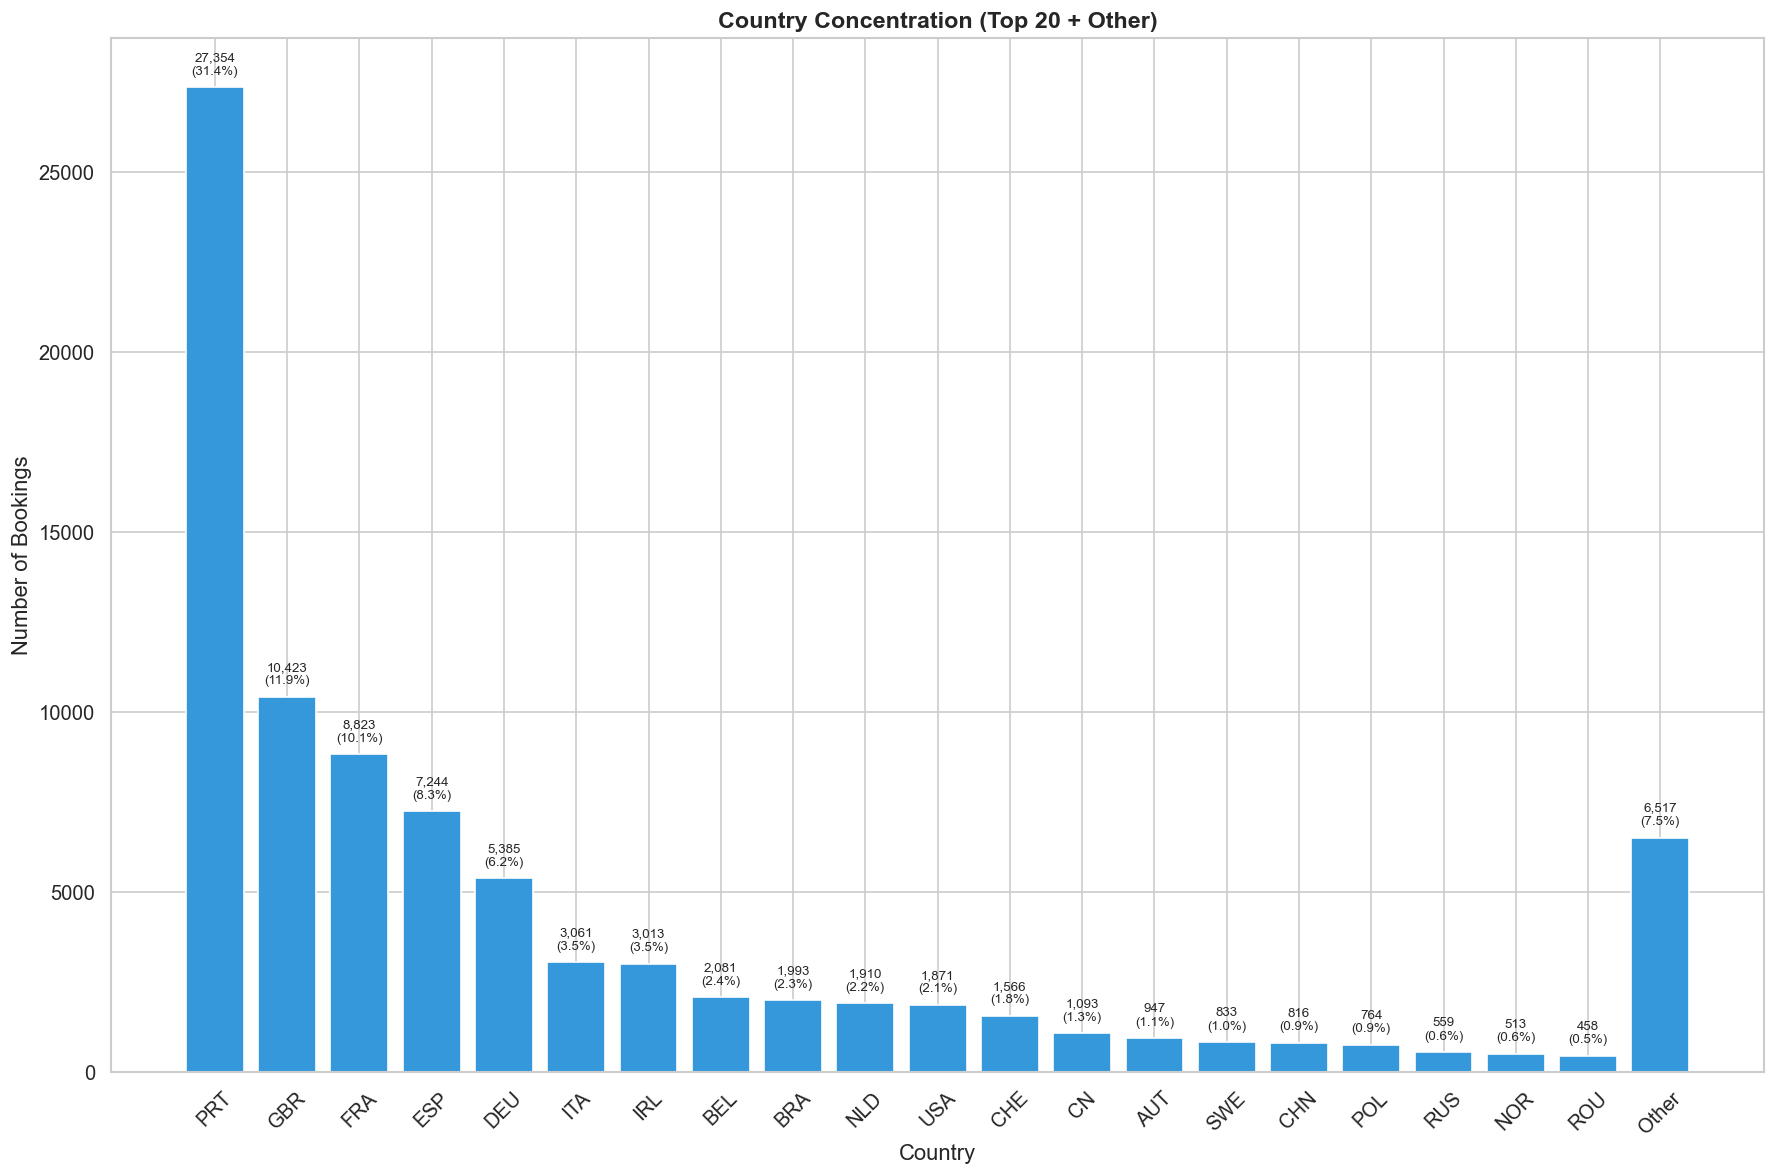

In [452]:
# country concentration
country_counts = df_clean['country'].value_counts(dropna=False)
top_n = 20
top_country = country_counts.head(top_n)
other_count = country_counts.iloc[top_n:].sum()

country_plot = top_country.copy()
country_plot.loc['Other'] = other_count
country_pct = (country_plot / country_plot.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(15, 10))
bars = ax.bar(country_plot.index.astype(str), country_plot.values, color='#3498DB')
ax.set_title('Country Concentration (Top 20 + Other)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Bookings')
ax.tick_params(axis='x', rotation=45)

y_offset = country_plot.max() * 0.01
for bar, c, p in zip(bars, country_plot.values, country_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
            f'{c:,}\n({p}%)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./eda_visuals/univariate/15_country_top20_other.png', bbox_inches='tight')
plt.show()

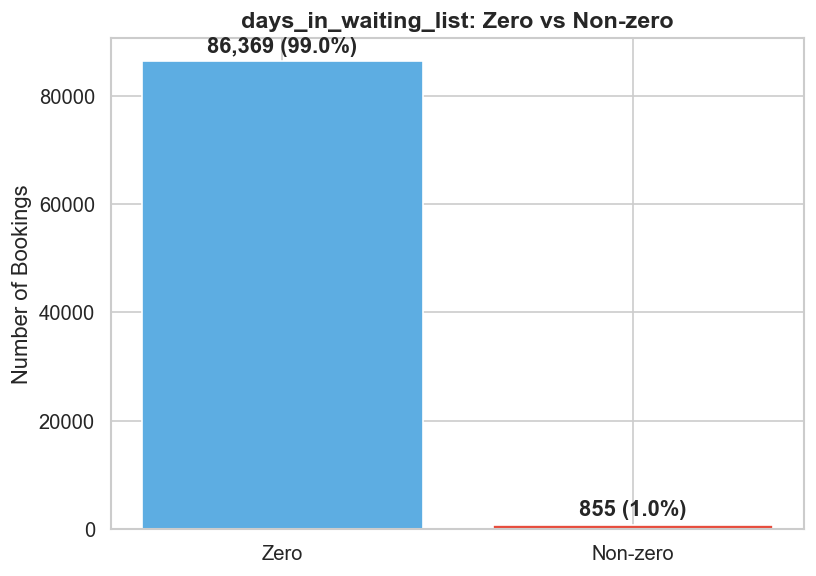

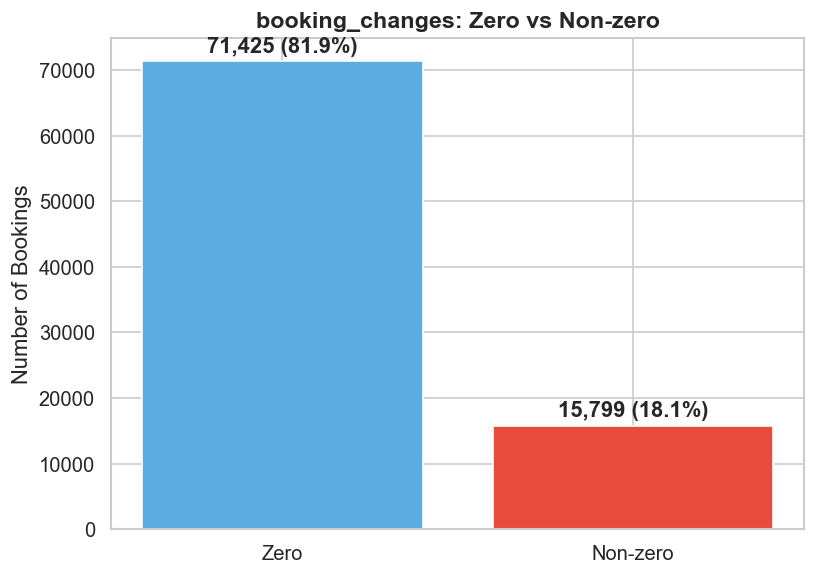

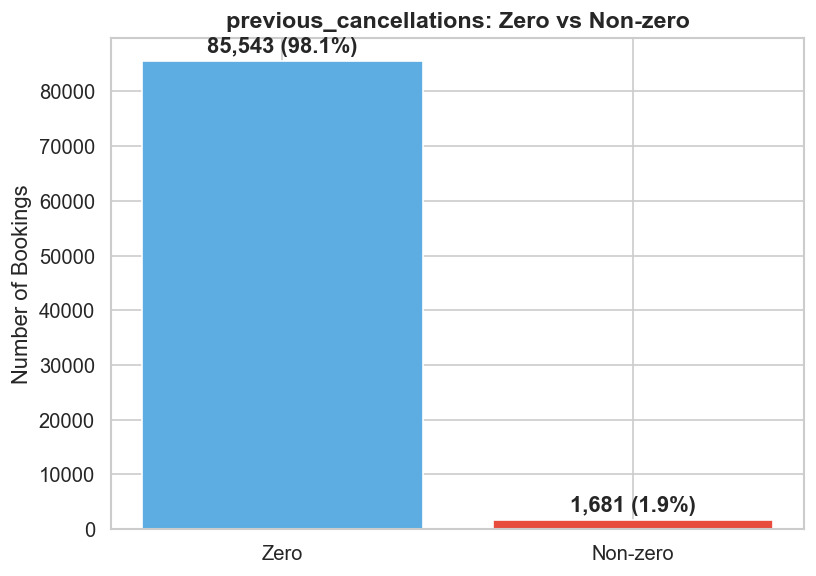

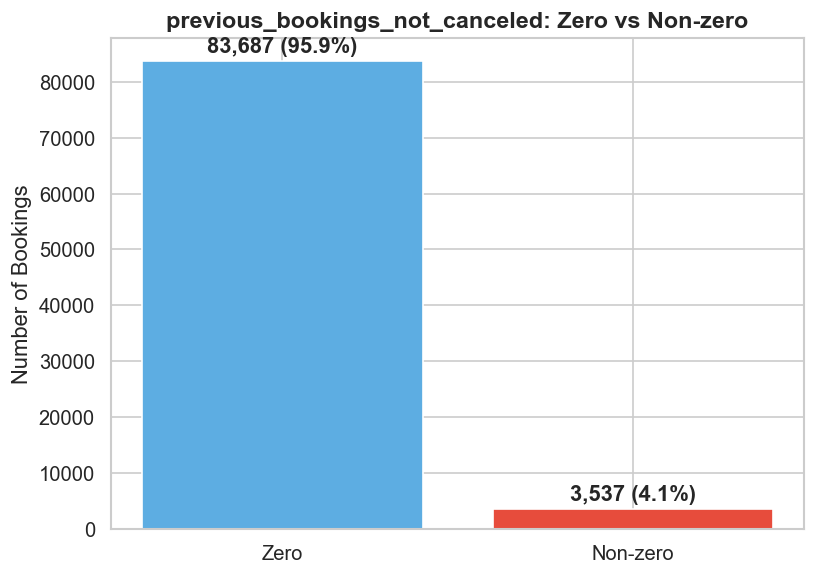

In [422]:
# zero-inflated feature profiles
feature_profiles = [
    ('days_in_waiting_list', '16_days_waiting_zero_nonzero.png'),
    ('booking_changes', '17_booking_changes_zero_nonzero.png'),
    ('previous_cancellations', '18_prev_cancellations_zero_nonzero.png'),
    ('previous_bookings_not_canceled', '19_prev_not_canceled_zero_nonzero.png'),
]

for col, name in feature_profiles:
    plot_zero_nonzero(df_clean, col, name)

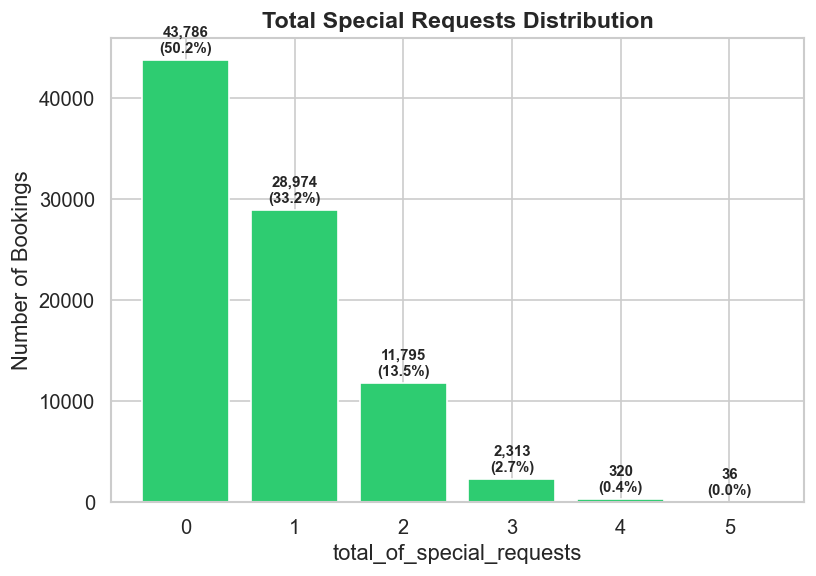

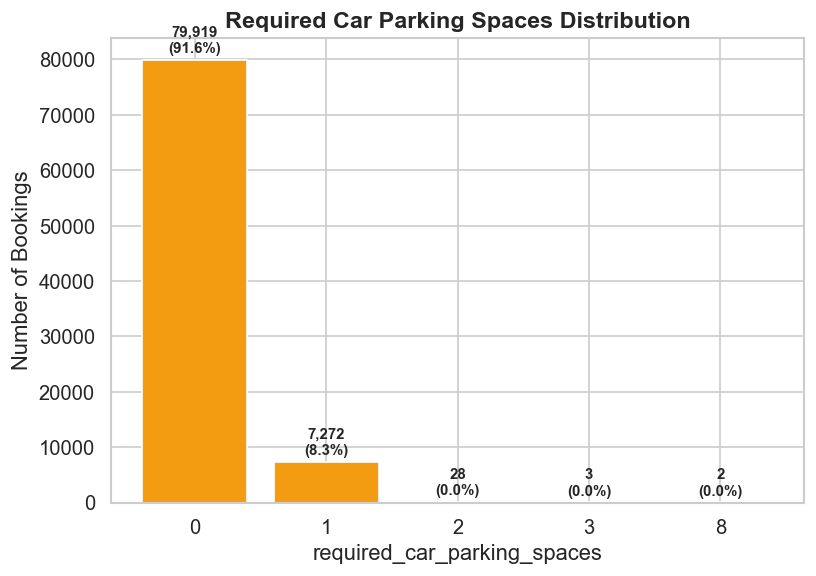

In [423]:
# special requests distribution
plot_count_pct(df_clean['total_of_special_requests'],
               'Total Special Requests Distribution',
               'total_of_special_requests',
               '20_special_requests_distribution.png',
               color='#2ECC71')

# parking spaces distribution
plot_count_pct(df_clean['required_car_parking_spaces'],
               'Required Car Parking Spaces Distribution',
               'required_car_parking_spaces',
               '21_parking_spaces_distribution.png',
               color='#F39C12')

In [424]:
# total nights and total guests
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']

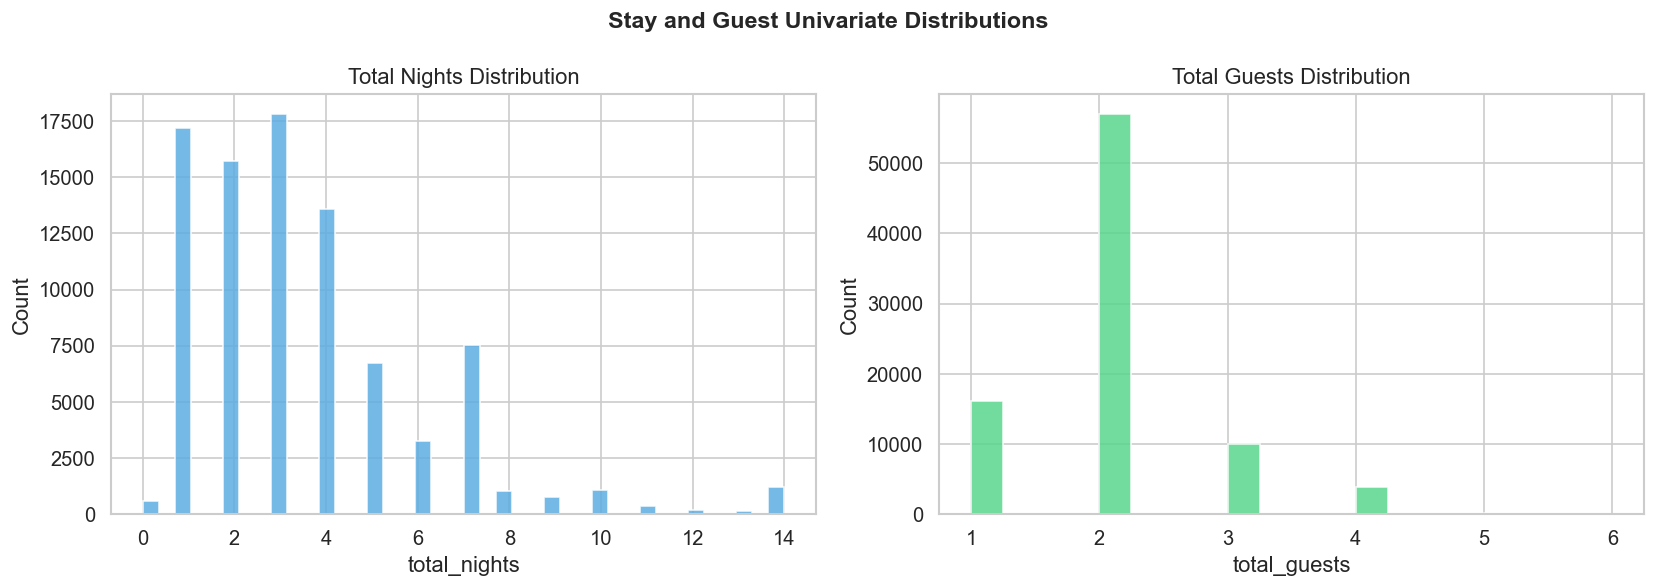

In [425]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['total_nights'], bins=40, color='#5DADE2', alpha=0.85)
axes[0].set_title('Total Nights Distribution')
axes[0].set_xlabel('total_nights')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean['total_guests'], bins=20, color='#58D68D', alpha=0.85)
axes[1].set_title('Total Guests Distribution')
axes[1].set_xlabel('total_guests')
axes[1].set_ylabel('Count')

plt.suptitle('Stay and Guest Univariate Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./eda_visuals/univariate/22_total_nights_total_guests.png', bbox_inches='tight')
plt.show()

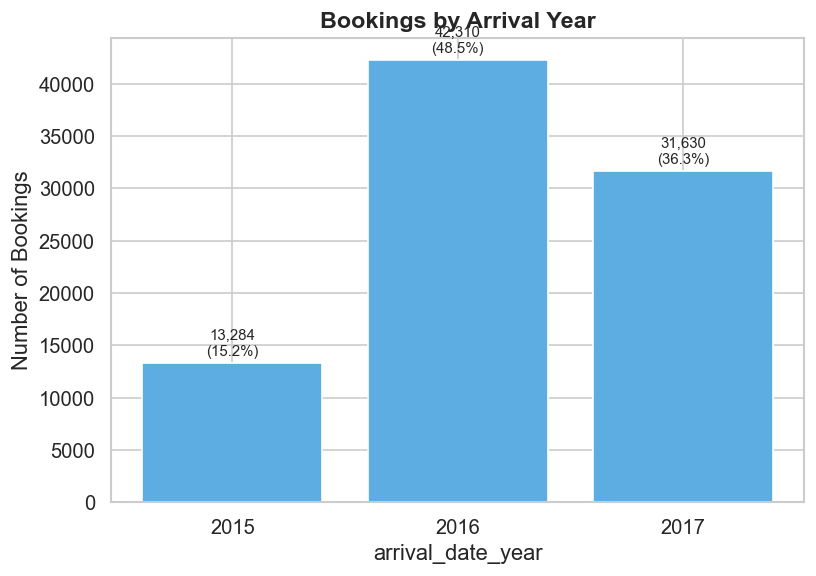

In [427]:
# date univariate seasonality
year_counts = df_clean['arrival_date_year'].value_counts().sort_index()
year_pct = (year_counts / len(df_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(year_counts.index.astype(str), year_counts.values, color='#5DADE2')
ax.set_title('Bookings by Arrival Year', fontsize=14, fontweight='bold')
ax.set_xlabel('arrival_date_year')
ax.set_ylabel('Number of Bookings')

y_offset = year_counts.max() * 0.01
for bar, c, p in zip(bars, year_counts.values, year_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
            f'{c:,}\n({p}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./eda_visuals/univariate/23_arrival_year_distribution.png', bbox_inches='tight')
plt.show()

In [428]:
# roommismatch
df_clean['is_room_changed'] = (df_clean['reserved_room_type'] != df_clean['assigned_room_type']).astype(int)

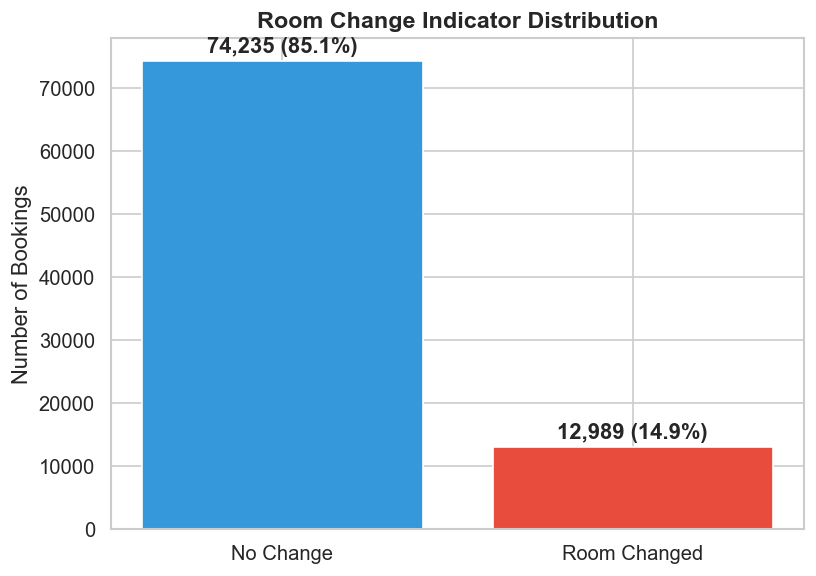

Room changed rate: 14.89%


In [429]:
room_change_counts = df_clean['is_room_changed'].value_counts().sort_index()
room_change_labels = ['No Change', 'Room Changed']
room_change_vals = [room_change_counts.get(0, 0), room_change_counts.get(1, 0)]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(room_change_labels, room_change_vals, color=['#3498DB', '#E74C3C'])
ax.set_title('Room Change Indicator Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Bookings')

for bar, v in zip(bars, room_change_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(room_change_vals)*0.01,
            f'{v:,} ({v/len(df_clean)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('./eda_visuals/univariate/24_room_changed_distribution.png', bbox_inches='tight')
plt.show()

print(f"Room changed rate: {room_change_vals[1] / len(df_clean) * 100:.2f}%")


### Bivariate analysis

                  mean    sum  count  rate
hotel                                     
City Hotel    0.300997  16035  53273  30.1
Resort Hotel  0.234780   7971  33951  23.5


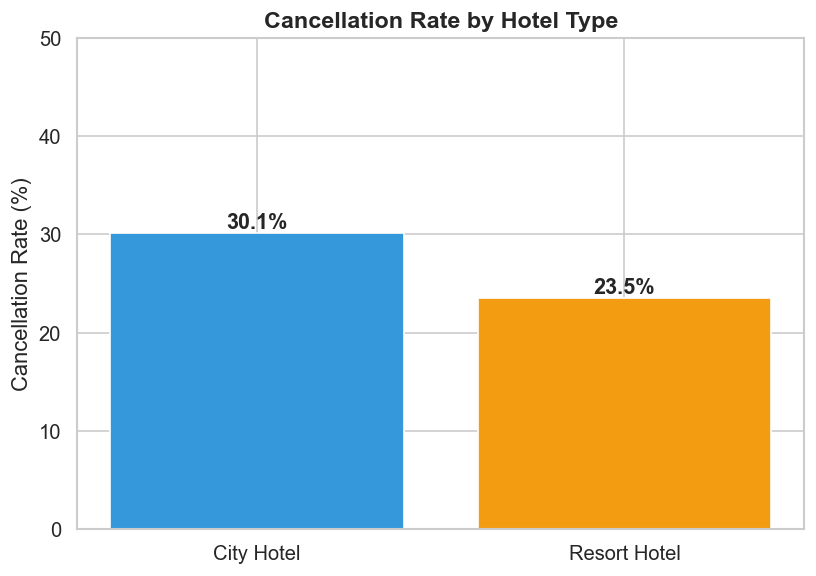

In [ ]:
# cancellation rate by hotel type
hotel_cancel = df_clean.groupby('hotel')['is_canceled'].agg(['mean','sum','count'])
hotel_cancel['rate'] = (hotel_cancel['mean'] * 100).round(1)
print(hotel_cancel)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(hotel_cancel.index, hotel_cancel['rate'],
              color=['#3498DB', '#F39C12'])
ax.set_title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, 50)
for bar, rate in zip(bars, hotel_cancel['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate}%', ha='center', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/2_cancellation_by_hotel.png', bbox_inches='tight')
plt.show()

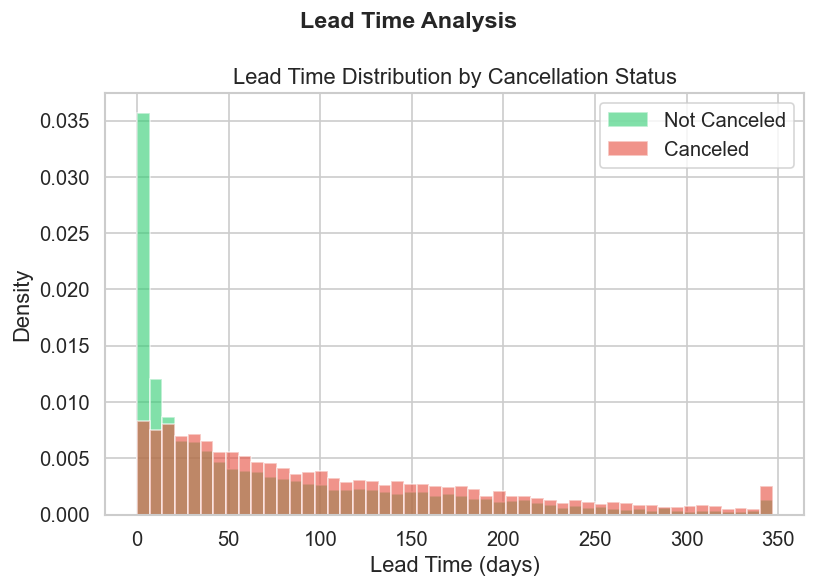

In [ ]:
# lead time distribution
fig, ax = plt.subplots(figsize=(7, 5))

# Histogram
for label, color, val in [('Not Canceled', '#2ECC71', 0),
                           ('Canceled', '#E74C3C', 1)]:
    ax.hist(df_clean[df_clean['is_canceled'] == val]['lead_time'],
                 bins=50, alpha=0.6, color=color, label=label, density=True)
ax.set_title('Lead Time Distribution by Cancellation Status')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Lead Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/3_lead_time.png', bbox_inches='tight')
plt.show()

- short lead time are mostly not canceled
- 20+ red bars are above green so cancellation becomes more likely --> should keep the feature

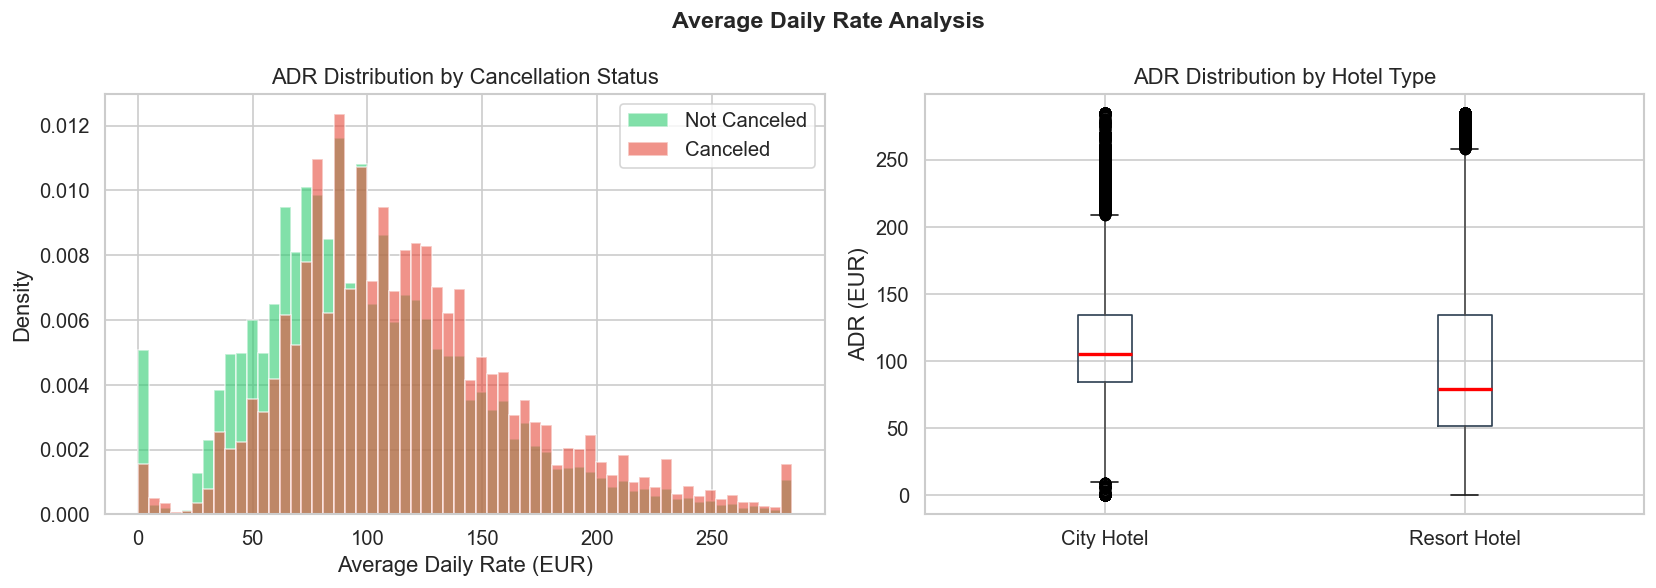

                count    mean    std  min    25%    50%    75%    max
hotel                                                                
City Hotel    53273.0  111.13  41.74  0.0  84.15  105.3  134.1  285.0
Resort Hotel  33951.0   98.73  62.63  0.0  51.50   79.5  134.1  285.0


In [ ]:
# adr distribution by cancellation and hotel type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By cancellation
for label, color, val in [('Not Canceled', '#2ECC71', 0),
                           ('Canceled', '#E74C3C', 1)]:
    axes[0].hist(df_clean[df_clean['is_canceled'] == val]['adr'],
                 bins=60, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('ADR Distribution by Cancellation Status')
axes[0].set_xlabel('Average Daily Rate (EUR)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot by hotel type
df_clean.boxplot(column='adr', by='hotel', ax=axes[1],
                boxprops=dict(color='#2C3E50'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('ADR Distribution by Hotel Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('ADR (EUR)')
plt.suptitle('')

plt.suptitle('Average Daily Rate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/4_adr_distribution.png', bbox_inches='tight')
plt.show()

print(df_clean.groupby('hotel')['adr'].describe().round(2))

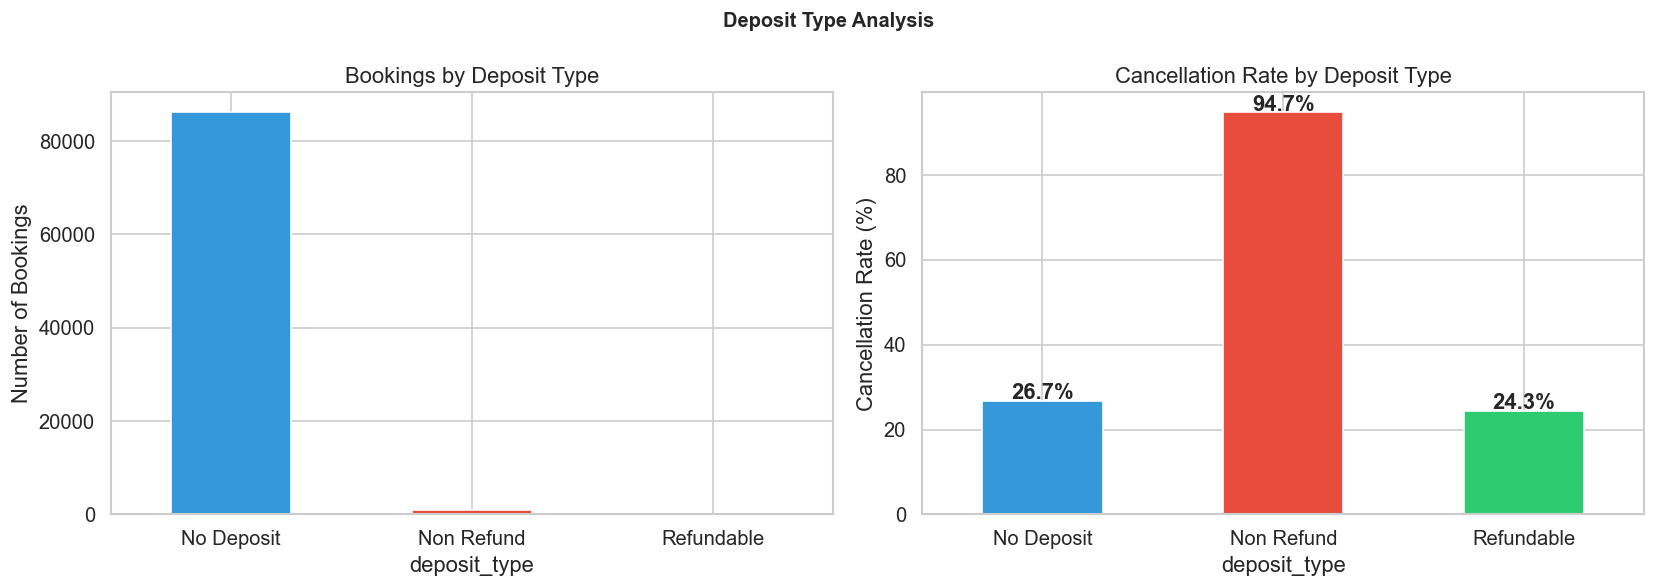

In [ ]:
# deposit type distribtion
deposit_counts  = df_clean['deposit_type'].value_counts()
deposit_cancel  = df_clean.groupby('deposit_type')['is_canceled'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deposit_counts.plot(kind='bar', ax=axes[0], color=['#3498DB','#E74C3C','#2ECC71'], rot=0)
axes[0].set_title('Bookings by Deposit Type')
axes[0].set_ylabel('Number of Bookings')

deposit_cancel.plot(kind='bar', ax=axes[1], color=['#3498DB','#E74C3C','#2ECC71'], rot=0)
axes[1].set_title('Cancellation Rate by Deposit Type')
axes[1].set_ylabel('Cancellation Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center', fontweight='bold')

plt.suptitle('Deposit Type Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/5_deposit_type.png', bbox_inches='tight')
plt.show()

deposit_type is strong predictor because 94.7% of non refundable is cancelled

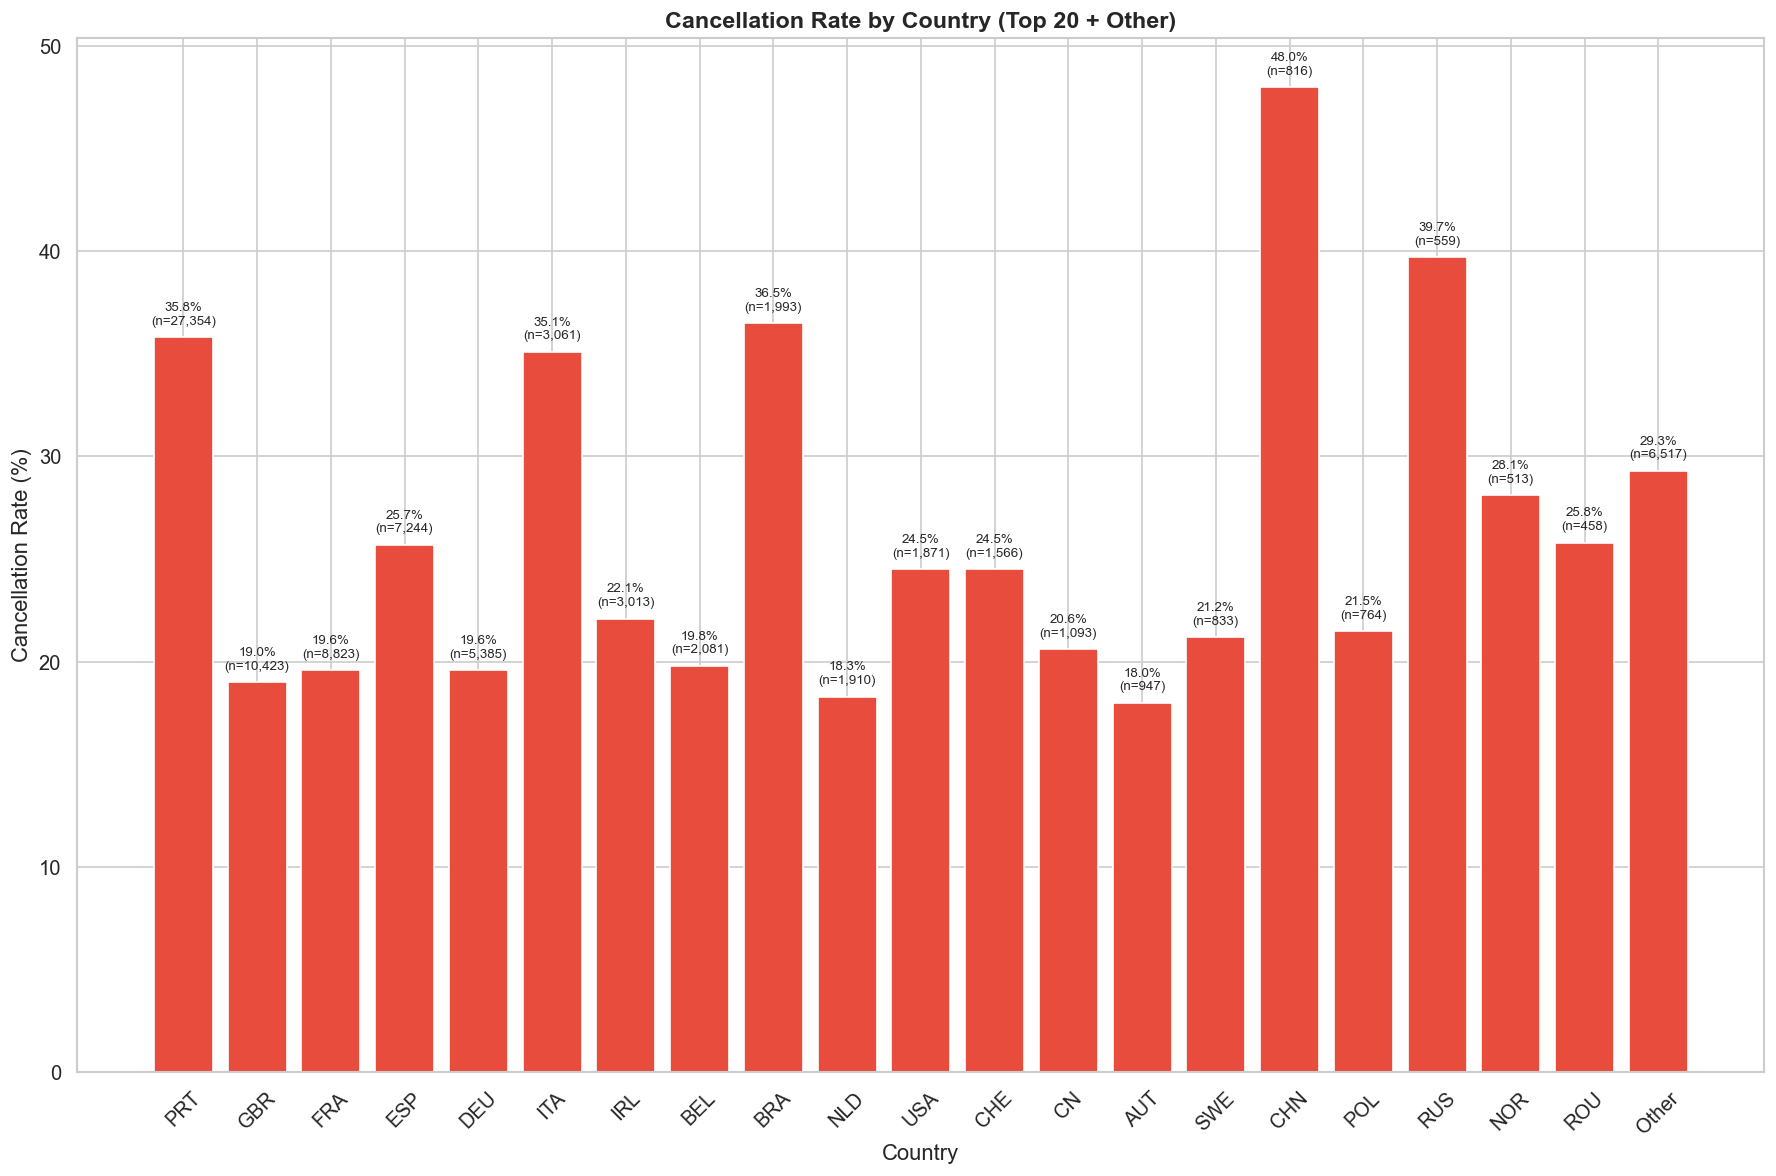

,total_bookings,canceled,cancel_rate_pct
country,,,
CHN,816,392,48.0
RUS,559,222,39.7
BRA,1993,727,36.5
PRT,27354,9782,35.8
ITA,3061,1075,35.1
Other,6517,1909,29.3
NOR,513,144,28.1
ROU,458,118,25.8
ESP,7244,1862,25.7


In [453]:
# cancellation analysis by country (Top 20 + Other)
country_stats = df_clean.groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
).sort_values('total_bookings', ascending=False)

top_n = 20
top_country_stats = country_stats.head(top_n).copy()

other = country_stats.iloc[top_n:].sum(numeric_only=True)
other_total = int(other['total_bookings'])
other_canceled = int(other['canceled'])
other_rate = (other_canceled / other_total) if other_total > 0 else 0.0

top_country_stats.loc['Other'] = {
    'total_bookings': other_total,
    'canceled': other_canceled,
    'cancel_rate': other_rate
}

top_country_stats['cancel_rate_pct'] = (top_country_stats['cancel_rate'] * 100).round(1)

# plot cancellation rate
fig, ax = plt.subplots(figsize=(15, 10))
bars = ax.bar(top_country_stats.index.astype(str), top_country_stats['cancel_rate_pct'].values, color='#E74C3C')
ax.set_title('Cancellation Rate by Country (Top 20 + Other)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Cancellation Rate (%)')
ax.tick_params(axis='x', rotation=45)

y_offset = top_country_stats['cancel_rate_pct'].max() * 0.01
for bar, r, n in zip(bars, top_country_stats['cancel_rate_pct'].values, top_country_stats['total_bookings'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
            f'{r:.1f}%\n(n={int(n):,})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./eda_visuals/bivariate/country_cancellation_rate_top20_other.png', bbox_inches='tight')
plt.show()

# optional table for exact values
display(
    top_country_stats[['total_bookings', 'canceled', 'cancel_rate_pct']]
    .sort_values('cancel_rate_pct', ascending=False)
)


In [431]:
# turn year month day into date 
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_month_num'].astype(str).str.zfill(2) + '-' +
    df_clean['arrival_date_day_of_month'].astype(str).str.zfill(2)
)

                total  cancel_rate  avg_adr  avg_lead_time
market_segment                                            
Undefined           2        100.0    15.00            2.0
Online TA       51548         35.4   118.14           80.0
Groups           4921         27.1    75.07          141.0
Aviation          226         19.9   100.61            4.0
Offline TA/TO   13855         14.8    81.55          105.0
Direct          11780         14.7   116.43           49.0
Complementary     692         12.3     3.09           14.0
Corporate        4200         12.1    68.28           16.0


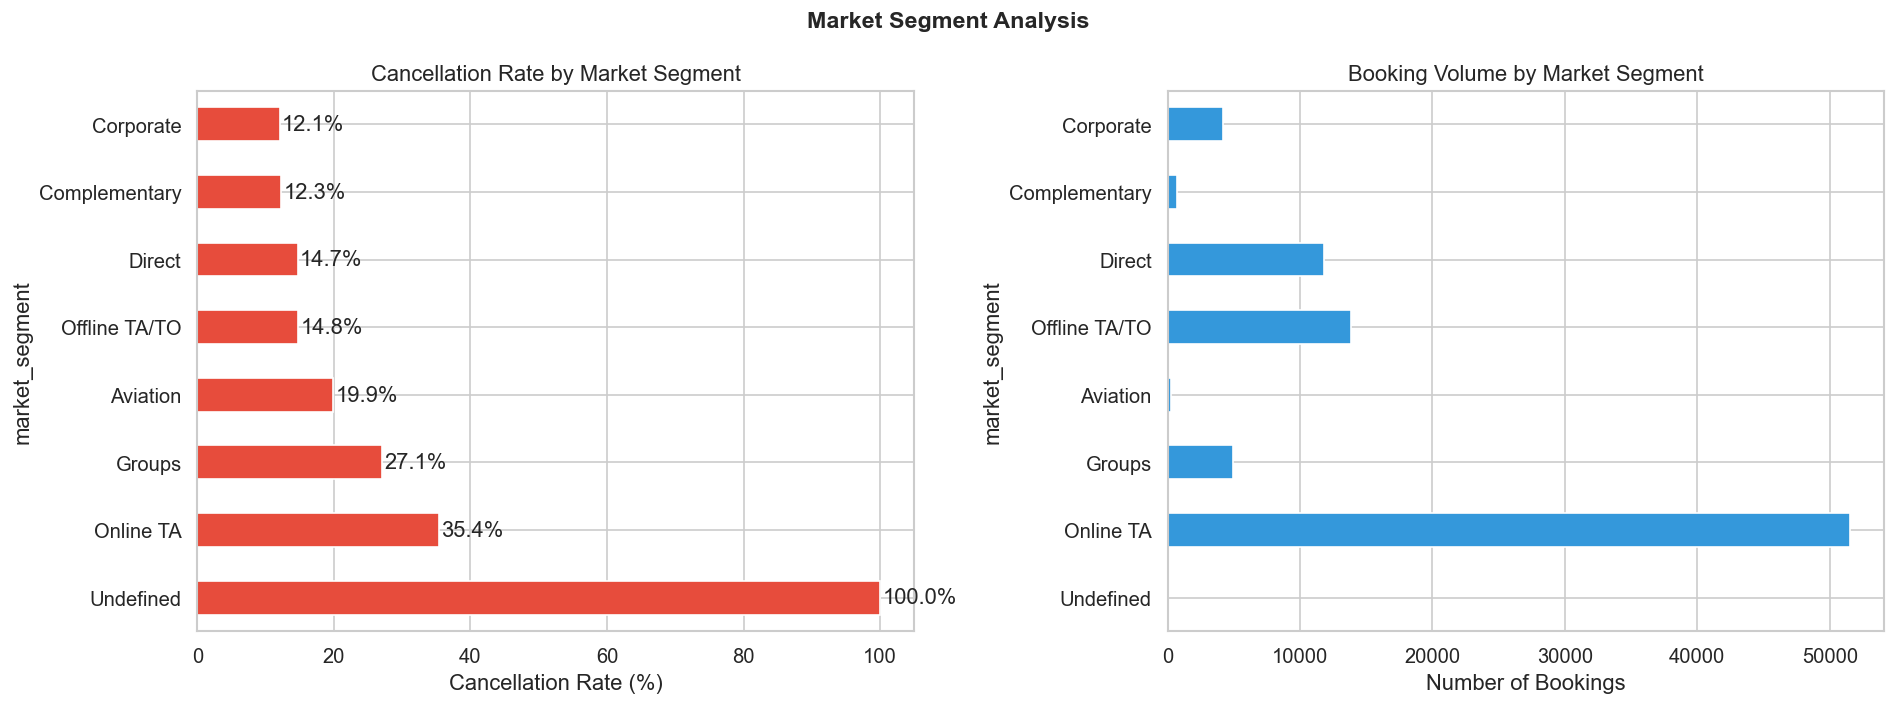

In [ ]:
# cancellation rate by market segment
# “TA” means “Travel Agents” and “TO” means “Tour Operators”

segment_stats = df_clean.groupby('market_segment').agg(
    total=('is_canceled','count'),
    cancel_rate=('is_canceled','mean'),
    avg_adr=('adr','mean'),
    avg_lead_time=('lead_time','mean')
).sort_values('cancel_rate', ascending=False)
segment_stats['cancel_rate'] = (segment_stats['cancel_rate'] * 100).round(1)
segment_stats['avg_adr'] = segment_stats['avg_adr'].round(2)
segment_stats['avg_lead_time'] = segment_stats['avg_lead_time'].round(0)

print(segment_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_stats['cancel_rate'].plot(kind='barh', ax=axes[0], color='#E74C3C')
axes[0].set_title('Cancellation Rate by Market Segment')
axes[0].set_xlabel('Cancellation Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%',
                     (p.get_width() + 0.3, p.get_y() + p.get_height()/2),
                     va='center')

segment_stats['total'].plot(kind='barh', ax=axes[1], color='#3498DB')
axes[1].set_title('Booking Volume by Market Segment')
axes[1].set_xlabel('Number of Bookings')

plt.suptitle('Market Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/08_market_segment.png', bbox_inches='tight')
plt.show()

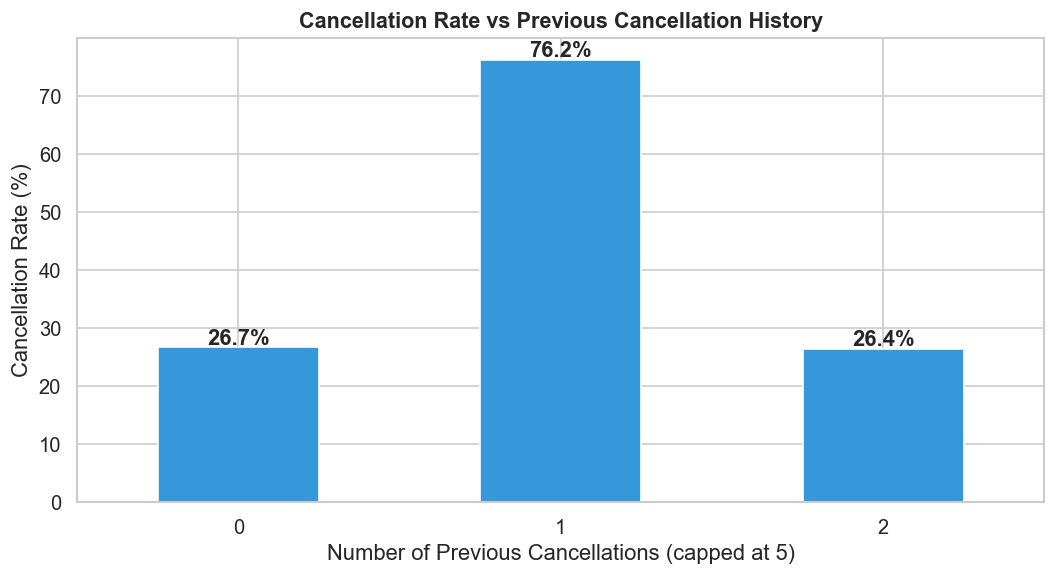

In [437]:
# prev vs current cancellation
prev_cancel_rate = df_clean.groupby(
    df_clean['previous_cancellations'].clip(0, 5)  # cap at 5 for readability
)['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
prev_cancel_rate.plot(kind='bar', ax=ax, color='#3498DB', rot=0)
ax.set_title('Cancellation Rate vs Previous Cancellation History',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Previous Cancellations (capped at 5)')
ax.set_ylabel('Cancellation Rate (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/09_previous_cancellations.png', bbox_inches='tight')
plt.show()

76% of ppl who had a previous cancelation end up canceling so its an important feature

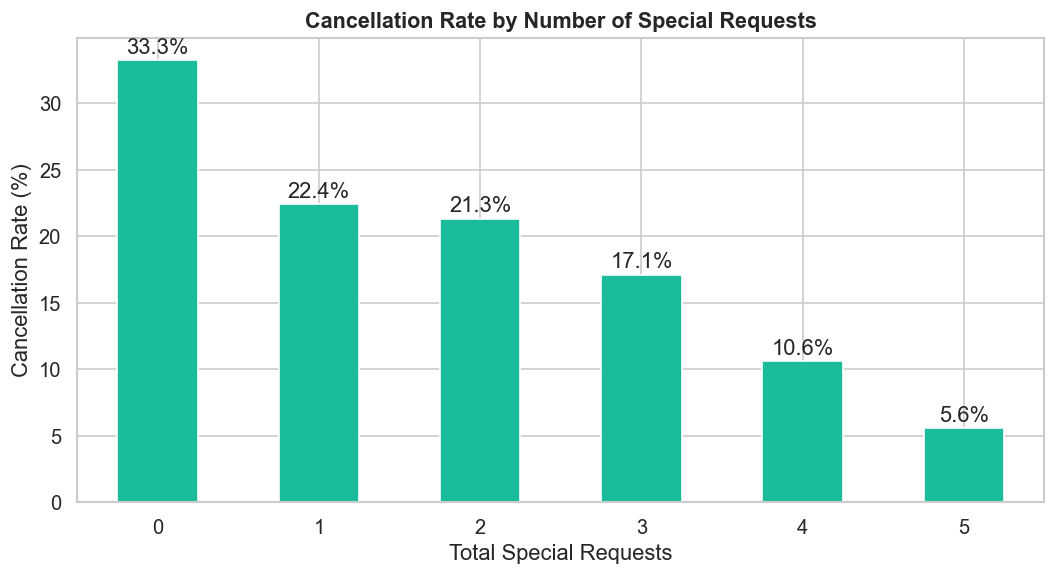

In [438]:
# 
special_req_rate = df_clean.groupby('total_of_special_requests')['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
special_req_rate.plot(kind='bar', ax=ax, color='#1ABC9C', rot=0)
ax.set_title('Cancellation Rate by Number of Special Requests',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Special Requests')
ax.set_ylabel('Cancellation Rate (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/10_special_requests.png', bbox_inches='tight')
plt.show()

more special requests means less likely to cancel

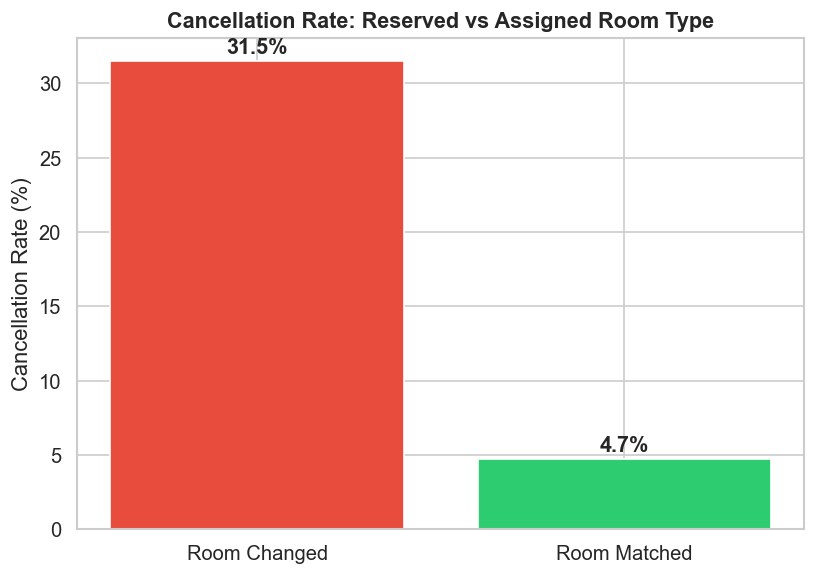

In [440]:
room_match_rate = df_clean.groupby('is_room_changed')['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Room Changed', 'Room Matched'], room_match_rate.values,
       color=[COLORS['canceled'], COLORS['not_canceled']])
ax.set_title('Cancellation Rate: Reserved vs Assigned Room Type',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
for i, v in enumerate(room_match_rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/11_room_match.png', bbox_inches='tight')
plt.show()

room change is more likely to cancel booking

#### Time series, good for dashboard

In [442]:
df_clean['revenue_at_risk'] = (df_clean['adr'] * df_clean['total_nights']).round(2)

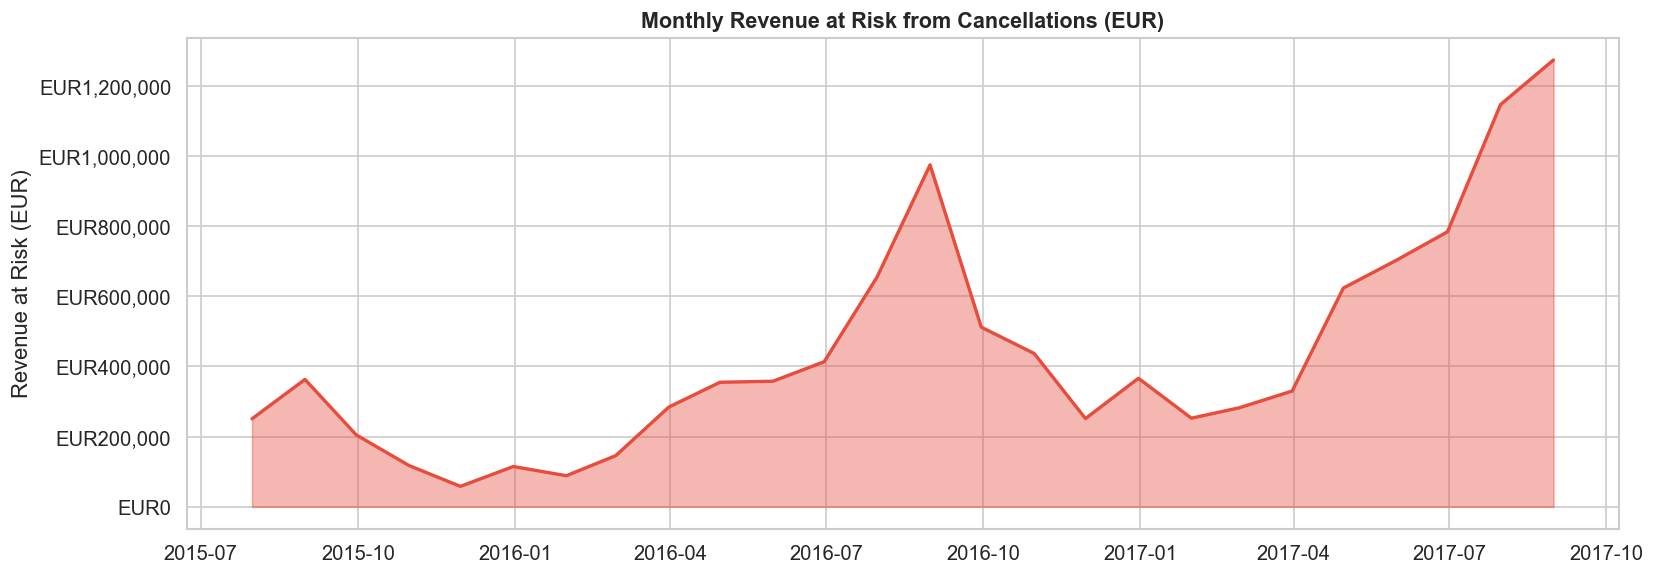

Total revenue at risk from cancellations: EUR11,342,439.19


In [444]:
# revenue at risk from cancellations
# !!!!!!!!! this is good for dashboard but can be misleading if not explained well, as it assumes all cancellations are lost revenue and doesn't account for potential rebookings or partial losses. Use with caution and clear context.
rev_by_month = df_clean[df_clean['is_canceled'] == 1].groupby(
    pd.Grouper(key='arrival_date', freq='ME')
)['revenue_at_risk'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(rev_by_month.index, rev_by_month.values,
                alpha=0.4, color='#E74C3C')
ax.plot(rev_by_month.index, rev_by_month.values,
        color='#E74C3C', linewidth=2)
ax.set_title('Monthly Revenue at Risk from Cancellations (EUR)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue at Risk (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR{x:,.0f}'))
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/12_revenue_at_risk.png', bbox_inches='tight')
plt.show()

total_rev_risk = df_clean[df_clean['is_canceled'] == 1]['revenue_at_risk'].sum()
print(f'Total revenue at risk from cancellations: EUR{total_rev_risk:,.2f}')

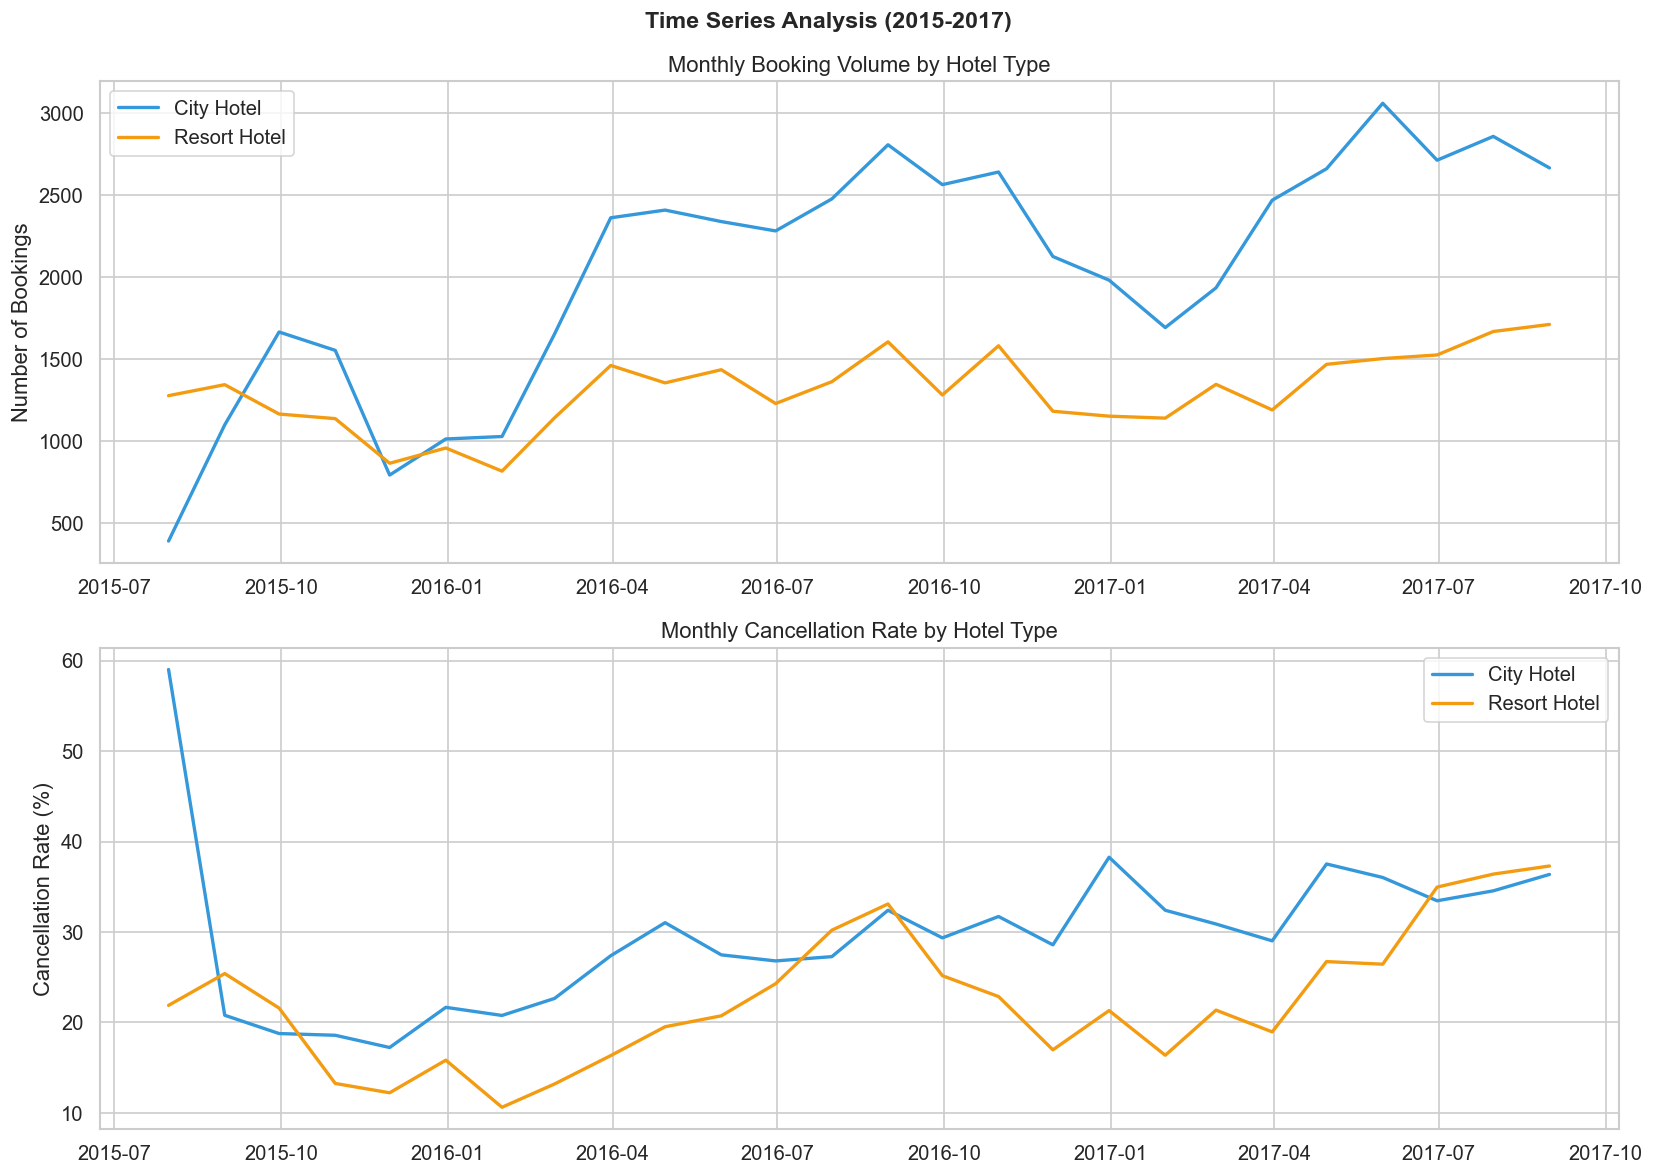

In [433]:
# cancellation rate by month and year
monthly = df_clean.groupby(['arrival_date_year', 'arrival_month_num']).agg(
    total=('is_canceled','count'),
    canceled=('is_canceled','sum')
).reset_index()
monthly['cancel_rate'] = monthly['canceled'] / monthly['total'] * 100
monthly['period'] = pd.to_datetime(
    monthly['arrival_date_year'].astype(str) + '-' +
    monthly['arrival_month_num'].astype(str).str.zfill(2) + '-01'
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Booking volume
for hotel, color in [('City Hotel', '#3498DB'), ('Resort Hotel', '#F39C12')]:
    sub = df_clean[df_clean['hotel'] == hotel].groupby(
        pd.Grouper(key='arrival_date', freq='ME')
    ).size()
    axes[0].plot(sub.index, sub.values, label=hotel, color=color, linewidth=2)
axes[0].set_title('Monthly Booking Volume by Hotel Type')
axes[0].set_ylabel('Number of Bookings')
axes[0].legend()

# Cancellation rate over time
for hotel, color in [('City Hotel', '#3498DB'), ('Resort Hotel', '#F39C12')]:
    sub = df_clean[df_clean['hotel'] == hotel].groupby(
        pd.Grouper(key='arrival_date', freq='ME')
    )['is_canceled'].mean() * 100
    axes[1].plot(sub.index, sub.values, label=hotel, color=color, linewidth=2)
axes[1].set_title('Monthly Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].legend()

plt.suptitle('Time Series Analysis (2015-2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/06_time_series.png', bbox_inches='tight')
plt.show()

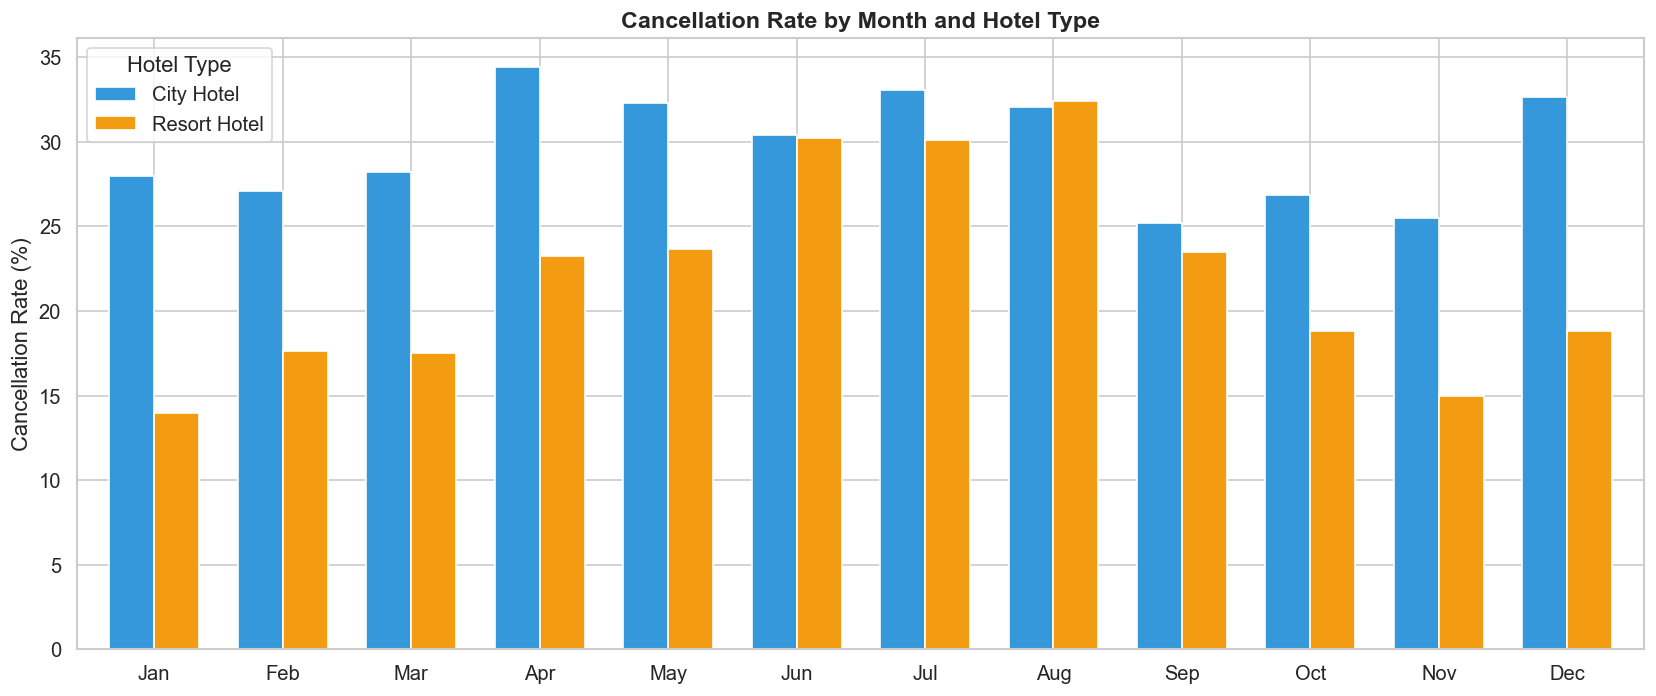

In [434]:
# seasonality cancellation rate by month and hotel type
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

seasonal = df_clean.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean() * 100
seasonal = seasonal.unstack('hotel').reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 6))
seasonal.plot(kind='bar', ax=ax, color=[COLORS['city'], COLORS['resort']], width=0.7)
ax.set_title('Cancellation Rate by Month and Hotel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('')
ax.set_xticklabels([m[:3] for m in month_order], rotation=0)
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('eda_visuals/bivariate/07_seasonality.png', bbox_inches='tight')
plt.show()

### Multivariate analysis

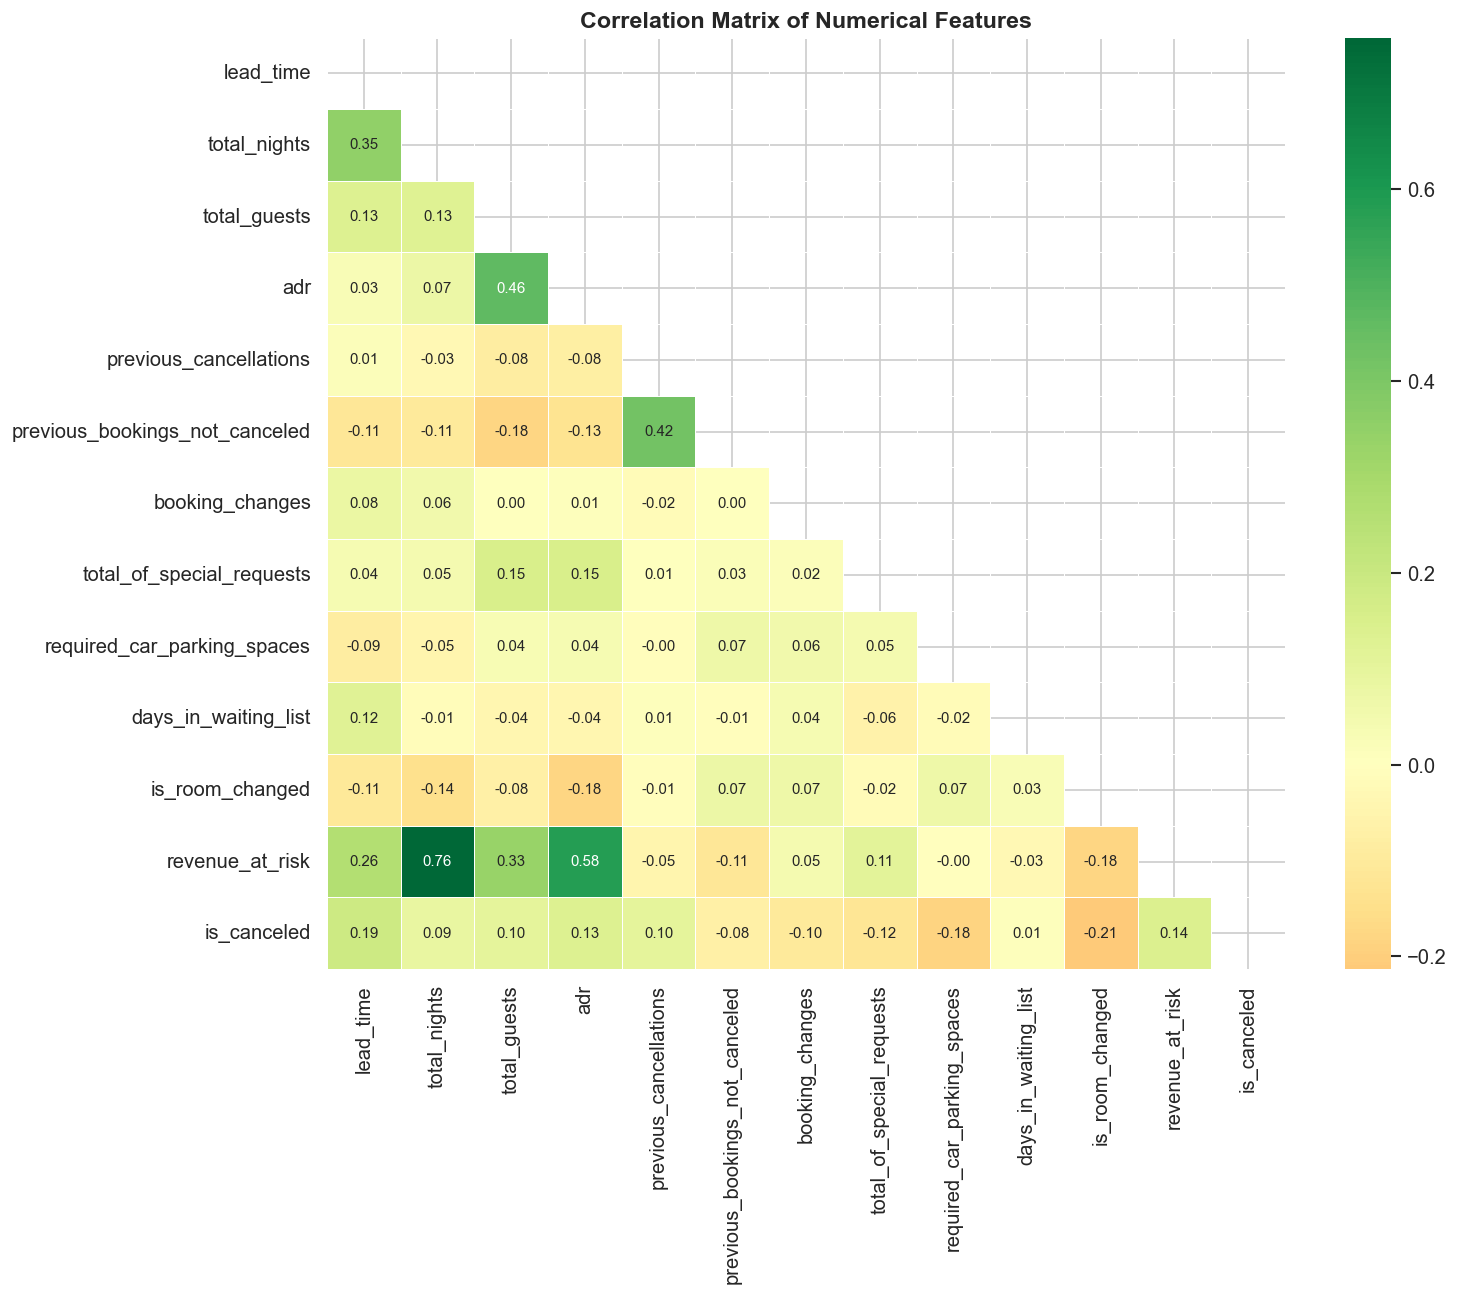

In [448]:
# correlation heatmap of numerical features
num_cols = ['lead_time','total_nights','total_guests','adr',
            'previous_cancellations','previous_bookings_not_canceled',
            'booking_changes','total_of_special_requests',
            'required_car_parking_spaces','days_in_waiting_list',
            'is_room_changed','revenue_at_risk', 'is_canceled']

corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix of Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visuals/multivariate/13_correlation_heatmap.png', bbox_inches='tight')
plt.show()

no autocorrelation

In [454]:
df_country_lookup = pd.read_csv('./data/country_lookup.csv')

In [ ]:
# merge continent and region info
df_clean = df_clean.merge(
    df_country_lookup.rename(columns={'country_code': 'country'}),
    on='country', how='left'
)
df_clean['continent'] = df_clean['continent'].fillna('Other')
df_clean['region']    = df_clean['region'].fillna('Other')


Cancellation rate by continent:
            total  cancel_rate     avg_adr
continent                                 
Africa       1025         44.1  119.642937
Asia         3656         34.2  116.896228
Americas     4473         29.7  118.664934
Europe      77173         27.0  105.099030
Oceania       448         21.9  118.100045
Other         447          6.5   61.957427
Antarctica      2          0.0  134.250000


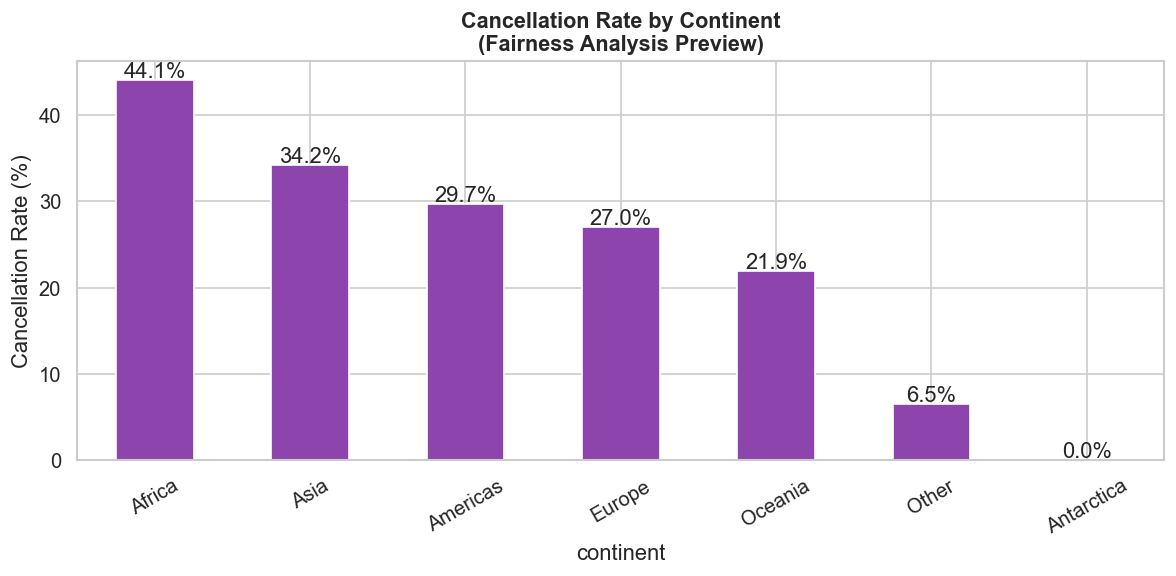

In [457]:
# continent level cancelation (for bias analysis)
continent_stats = df_clean.groupby('continent').agg(
    total=('is_canceled','count'),
    cancel_rate=('is_canceled','mean'),
    avg_adr=('adr','mean')
).sort_values('cancel_rate', ascending=False)
continent_stats['cancel_rate'] = (continent_stats['cancel_rate'] * 100).round(1)

print('Cancellation rate by continent:')
print(continent_stats)

fig, ax = plt.subplots(figsize=(10, 5))
continent_stats['cancel_rate'].plot(kind='bar', ax=ax, color='#8E44AD', rot=30)
ax.set_title('Cancellation Rate by Continent\n(Fairness Analysis Preview)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                ha='center')
plt.tight_layout()
plt.savefig('eda_visuals/multivariate/16_continent_fairness.png', bbox_inches='tight')
plt.show()

In [458]:
# lead time buckets
df_clean['lead_time_bucket'] = pd.cut(
    df_clean['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 9999],
    labels=['Same week','1-4 weeks','1-3 months','3-6 months','6-12 months','12+ months']
)


In [459]:
all_new_features = [
    "arrival_month_num",
    "arrival_date",
    "total_nights",
    "total_guests",
    "is_room_changed",
    "revenue_at_risk",
    "lead_time_log",
    "adr_log",
    "previous_cancellations_log",
    "previous_bookings_not_canceled_log",
    "days_in_waiting_list_log",
    "has_waiting_list",
    "has_prev_cancellations",
    "has_prev_not_canceled",
    "has_booking_changes",
    "has_any_history",
    "prev_cancel_ratio",
    "continent",
    "region",
    "lead_time_bucket"
]

### Export engineered dataset

In [460]:
# saving this for baseline testing 
df_clean.to_csv('./data/hotel_bookings_feature_engineered.csv', index=False)